# humidity

In [1]:
import pandas as pd

In [2]:
district = 'Kushtia'
df_district = pd.read_csv(f'../../../1980-2024-dataset/{district}_historical_weather_1980_2024.csv')

df_district = df_district.drop('district', axis =1 )

desired_colmn = ['day', 'month', 'year', 'humidity']
df_district = df_district[desired_colmn]

df_district = df_district.dropna()

df_district.head()

,day,month,year,humidity
0,1,1,1980,69.4
1,2,1,1980,90.2
2,3,1,1980,85.8
3,4,1,1980,78.4
4,5,1,1980,87.7


Date range: 2014-01-01 to 2024-12-31


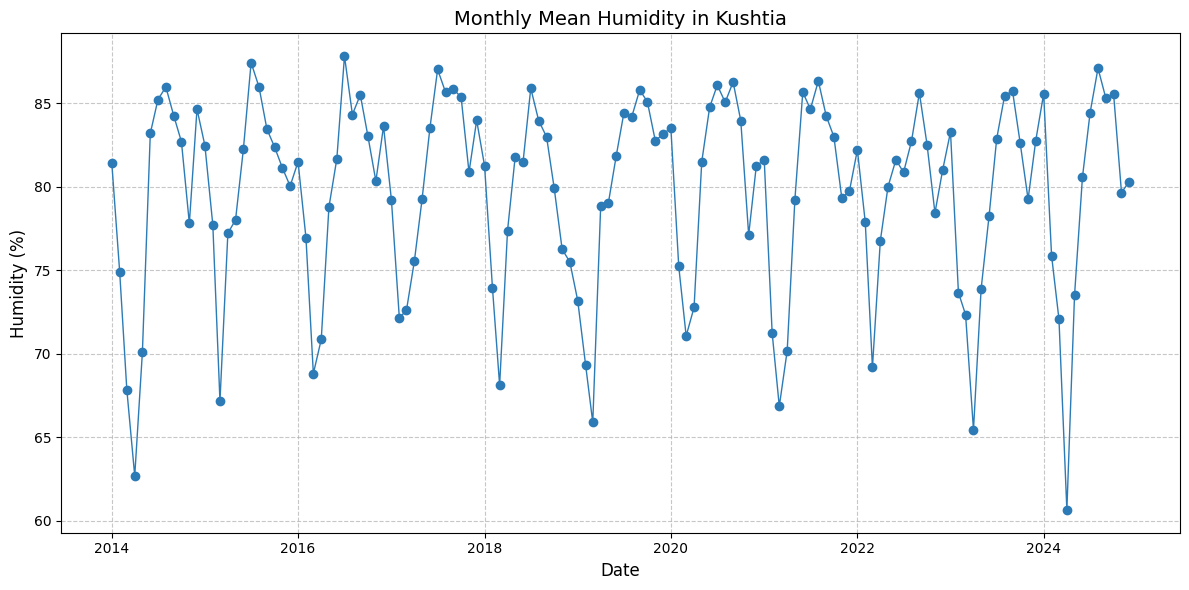

In [3]:
import matplotlib.pyplot as plt

if 'date' not in df_district.columns:
    df_district['date'] = pd.to_datetime(df_district[['year', 'month', 'day']])

# # show date range
# min_date = df_district['date'].min()
# max_date = df_district['date'].max()
# print(f"Date range: {min_date.date()} to {max_date.date()}")

# 2010-2024 dile 83% r2 lightgbm
# 2014- 2024 dile 82% R2
# 2018-2024 dile 52% R2 xgboost

# filter data for custom date range: 2020 to 2024
df_district = df_district[
    (df_district['date'] >= '2014-01-01') & (df_district['date'] <= '2024-12-31')
]
custom_range_df = df_district.copy()

# show date range
min_date = custom_range_df['date'].min()
max_date = custom_range_df['date'].max()

df_district['date'] = pd.to_datetime(df_district['date'])
df_district.set_index('date', inplace=True)

df_monthly_hum = df_district['humidity'].resample('MS').mean()
# Fill missing gaps using linear interpolation (common for weather data)
df_monthly_hum = df_monthly_hum.interpolate(method='linear')

print(f"Date range: {min_date.date()} to {max_date.date()}")

# --- Plotting ---
plt.figure(figsize=(12, 6))
plt.plot(df_monthly_hum, marker='o', linestyle='-', color='#2c7bb6', linewidth=1)
plt.title(f'Monthly Mean Humidity in {district}', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Humidity (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Prepare Monthly Data
df = df_district.copy() # [cite: 101]
df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) 

# pchip: Piecewise Cubic Hermite Interpolating Polynomial

df_monthly_hum = df.set_index('date')['humidity'].resample('MS').mean().reset_index()
df_monthly_hum = df_monthly_hum.interpolate(method='linear').dropna()

# 2. Engineering Fourier Features for Seasonality
# This replaces the need for interpolation/splines
def add_fourier_features(df, period=12, n_terms=3): # Monthly period is 12
    for n in range(1, n_terms + 1):
        # Using month index (1-12) as the base for the cycle
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly_hum.copy())
df_features['year_val'] = df_features['date'].dt.year

# 3. Define Features and Target
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]



In [5]:
df_monthly_hum.head()

,date,humidity
0,2014-01-01,81.441935
1,2014-02-01,74.900000
2,2014-03-01,67.838710
3,2014-04-01,62.673333
4,2014-05-01,70.083871


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score,TimeSeriesSplit

FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['humidity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True)


## RF hum

In [7]:
# param_grid_rf = {
#     'n_estimators': [100, 300, 500],
#     'max_depth': [3, 4, 6],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [7, 12, 20],   # Equivalent to min_child_samples
#     'max_features': [0.7, 'sqrt'],      # Feature bagging
#     'max_samples': [0.7, 0.8],          # Observation bagging
#     'bootstrap': [True]
# }

In [8]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score,TimeSeriesSplit

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6, 
    min_samples_split=2,
    min_samples_leaf=7,
    random_state=42,
    n_jobs=-1,
    max_features= 1.0
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

rf_r2_f  = r2_score(y_test, y_pred)
rf_mse_f = mean_squared_error(y_test, y_pred)
rf_rmse_f = np.sqrt(rf_mse_f)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

rf_acc_05 = tolerance_accuracy(y_test.values, y_pred, 0.5)
rf_acc_10 = tolerance_accuracy(y_test.values, y_pred, 1.0)
rf_acc_20 = tolerance_accuracy(y_test.values, y_pred, 2.0)
rf_acc_30 = tolerance_accuracy(y_test.values, y_pred, 3.0)

print("=== Random Forest + Fourier – Humidity Prediction (Test) ===")
print(f"R²          : {rf_r2_f:.4f}")
print(f"RMSE        : {rf_rmse_f:.3f} °C")
print(f"MSE         : {rf_mse_f:.4f}")
print("Accuracy (± tolerance):")
print(f"  ±0.5 °C : {rf_acc_05 * 100:5.2f}%")
print(f"  ±1.0 °C : {rf_acc_10 * 100:5.2f}%")
print(f"  ±2.0 °C : {rf_acc_20 * 100:5.2f}%")
print(f"  ±3.0 °C : {rf_acc_30 * 100:5.2f}%")

# ------------------------------------------------------------------
# 9. 5-fold CV (R²)
# ------------------------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)

# 2. Run cross-validation using the tscv object
rf_cv_r2 = cross_val_score(rf, X, y, cv=tscv, scoring='r2', n_jobs=-1)

print("\n=== TimeSeriesSplit CV R² (Seasonal Trend Validation) ===")
print(f"Mean R² : {rf_cv_r2.mean():.4f}  (±{rf_cv_r2.std():.4f})")
print(f"Scores  : {np.round(rf_cv_r2, 4)}")

fi = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))


=== Random Forest + Fourier – Humidity Prediction (Test) ===
R²          : 0.7917
RMSE        : 2.778 °C
MSE         : 7.7194
Accuracy (± tolerance):
  ±0.5 °C : 14.81%
  ±1.0 °C : 40.74%
  ±2.0 °C : 62.96%
  ±3.0 °C : 85.19%

=== TimeSeriesSplit CV R² (Seasonal Trend Validation) ===
Mean R² : 0.6331  (±0.1224)
Scores  : [0.4739 0.55   0.8377 0.6468 0.657 ]

=== Feature Importances (Top 10) ===
 feature  importance
   sin_1    0.852072
   sin_2    0.051008
   cos_1    0.040366
year_val    0.020755
   cos_2    0.019193
   cos_3    0.012329
   sin_3    0.004276


## XGBoost hum

In [9]:
# param_grid_xgb = {
#     'n_estimators': [100, 500],
#     'learning_rate': [0.01, 0.05],
#     'max_depth': [3, 4, 6],
#     'min_child_weight': [1, 5, 10],     # High values stop noise-chasing
#     'gamma': [0.1, 1, 5],               # Minimum loss reduction to split
#     'reg_alpha': [0.5, 1, 5],           # L1 regularization
#     'reg_lambda': [0.5, 1, 5],          # L2 regularization
#     'subsample': [0.7],
#     'colsample_bytree': [0.7]
# }

In [10]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor

xgb_model = xgb.XGBRegressor( 
    n_estimators=1000,          # Increased, but we will rely on a low learning rate
    learning_rate=0.01,         # Much lower to "crawl" toward the seasonal shape
    max_depth=4,                # Shallower trees prevent the model from memorizing specific years
    
    # --- Regularization to handle small N=132 ---
    reg_alpha=0.1,              # L1 regularization to keep feature weights stable
    reg_lambda=1.0,             # L2 regularization to prevent extreme predictions
    subsample=0.8,              # Use 80% of data per tree to add robustness
    colsample_bytree=0.8,       # Randomly select features to reduce dominance of sin_1
    
    # --- Optimization ---
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = xgb_model.predict(X_test)

xgboost_r2_f  = r2_score(y_test, y_pred)            # averaged R^2 for multioutput
xgboost_mse_f = mean_squared_error(y_test, y_pred)  # averaged MSE
xgboost_rmse_f = np.sqrt(xgboost_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    # returns fraction (0..1) of predictions within tol across all targets
    return ((np.abs(y_true - y_hat) <= tol).mean())

xgboost_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
xgboost_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
xgboost_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
xgboost_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== XGBoost Regression Metrics (Test) ====")
print(f"xgboost_R^2  : {xgboost_r2_f:.4f}")
print(f"xgboost_MSE  : {xgboost_mse_f:.4f}")
print(f"xgboost_RMSE : {xgboost_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {xgboost_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {xgboost_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {xgboost_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {xgboost_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)

xgb_cv_r2 = cross_val_score(xgb_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean xgboost_R^2 : {xgb_cv_r2.mean():.4f}  |  Std : {xgb_cv_r2.std():.4f}")

# --- 7) Feature importances (average across outputs) ---
# MultiOutputRegressor stores estimators_ after fit


fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.head(10).to_string(index=False))

==== XGBoost Regression Metrics (Test) ====
xgboost_R^2  : 0.8513
xgboost_MSE  : 5.5087
xgboost_RMSE : 2.3471
Accuracy (|error| ≤ tolerance):
  ±0.5°C : 18.52%
  ±1.0°C : 37.04%
  ±2.0°C : 62.96%
  ±3.0°C : 81.48%

==== 5-Fold CV R^2 ====
Mean xgboost_R^2 : 0.5624  |  Std : 0.1835

==== Top Feature Importances ====
 feature  importance
   sin_1    0.285921
   cos_2    0.263367
   sin_3    0.130505
   cos_3    0.100274
   sin_2    0.097191
   cos_1    0.082628
year_val    0.040115


## light gbm hum

In [11]:
# param_grid = {
#     'n_estimators': [100, 500],
#     'learning_rate': [0.01, 0.05],
#     'max_depth': [3, 4, 6],
#     'num_leaves': [5, 10, 20],
#     'min_child_samples': [10, 15, 25], # Higher helps with Bogra-style noise
#     'reg_alpha': [0.5, 1, 5],          # Increased L1 for sparsity
#     'reg_lambda': [0.5, 1, 5],         # Increased L2 for weight decay
#     'subsample': [0.7],
#     'colsample_bytree': [0.7]
# }

In [12]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor


# --- 4) Train MultiOutput LightGBM ---
import lightgbm as lgb

# Optimized for Seasonal Shape extraction on N=132
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,         # Slowed down for stable trend learning
    max_depth=4,                # Restricted depth to prevent memorizing noise
    num_leaves=10,              # Low number of leaves is critical for small data
    min_child_samples=5,        # Minimum data points in a leaf (prevents tiny, specific branches)
    
    subsample=0.7,              # Stochastic bagging for robustness
    subsample_freq=1,
    colsample_bytree=0.7,       # Feature bagging
    
    reg_alpha=0.2,              # L1 regularization
    reg_lambda=0.2,             # L2 regularization
    
    importance_type='gain',     # More useful for understanding "Shape" than 'split'
    random_state=42,
    n_jobs=-1,
    verbosity=-1                # Suppress warnings about small dataset
)

lgb_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = lgb_model.predict(X_test)

lgb_r2_f  = r2_score(y_test, y_pred)
lgb_mse_f = mean_squared_error(y_test, y_pred)
lgb_rmse_f = np.sqrt(lgb_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    return ((np.abs(y_true - y_hat) <= tol).mean())

lgb_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
lgb_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
lgb_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
lgb_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== LightGBM Regression Metrics (Test) ====")
print(f"LGB_R^2  : {lgb_r2_f:.4f}")
print(f"LGB_MSE  : {lgb_mse_f:.4f}")
print(f"LGB_RMSE : {lgb_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {lgb_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {lgb_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {lgb_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {lgb_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)
lgb_cv_r2 = cross_val_score(lgb_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean LGB_R^2 : {lgb_cv_r2.mean():.4f}  |  Std : {lgb_cv_r2.std():.4f}")



fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.to_string(index=False))


==== LightGBM Regression Metrics (Test) ====
LGB_R^2  : 0.8442
LGB_MSE  : 5.7724
LGB_RMSE : 2.4026
Accuracy (|error| ≤ tolerance):
  ±0.5°C : 22.22%
  ±1.0°C : 44.44%
  ±2.0°C : 70.37%
  ±3.0°C : 81.48%

==== 5-Fold CV R^2 ====
Mean LGB_R^2 : 0.6480  |  Std : 0.0944

==== Top Feature Importances ====
 feature   importance
   sin_1 64676.842402
year_val 19587.712288
   cos_2 12284.669405
   sin_2 12258.185623
   cos_1 10714.345987
   sin_3  9983.562519
   cos_3  6823.972750


## cat boost hum

In [13]:
# param_grid_cat = {
#     'iterations': [100, 500],           # Equivalent to n_estimators
#     'learning_rate': [0.01, 0.05],
#     'depth': [3, 4, 6],                 # Equivalent to max_depth
#     'l2_leaf_reg': [1, 5, 10, 20],      # High L2 to smooth the curve
#     'random_strength': [1, 2, 5],       # Adds noise to splits to prevent memorization
#     'bagging_temperature': [0.5, 1.0],  # Bayesian bagging control
#     'border_count': [32, 64],           # Fewer bins = more generalization
#     'grow_policy': ['SymmetricTree'],   # Usually most robust for small data
#     'verbose': [0]
# }

In [14]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
from catboost import CatBoostRegressor

# --- 4) Train MultiOutput LightGBM ---
cat_model = CatBoostRegressor(
    iterations=1500,           # Increased iterations with a lower learning rate
    learning_rate=0.01,        # "Crawl" toward the seasonal trend
    depth=4,                   # Shallower trees for better generalization on small N=132
    l2_leaf_reg=10,            # Higher L2 regularization to smooth the seasonal curve
    
    bootstrap_type='Bayesian',
    bagging_temperature=0.5,   # Reduced slightly for more stable bagging
    random_strength=2,         # Adds randomness to scoring splits, preventing overfitting
    
    loss_function='RMSE',      # Standard for regression; 'Huber' is also an option if data is noisy
    od_type='Iter',            # Overfitting detector
    od_wait=50,                # Stop early if the trend isn't improving
    
    random_seed=42,
    verbose=0
)


cat_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = cat_model.predict(X_test)

cat_r2_f  = r2_score(y_test, y_pred)
cat_mse_f = mean_squared_error(y_test, y_pred)
cat_rmse_f = np.sqrt(cat_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    return ((np.abs(y_true - y_hat) <= tol).mean())

cat_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
cat_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
cat_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
cat_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== CatBoost Regression Metrics (Test) ====")
print(f"CatBoost_R^2  : {cat_r2_f:.4f}")
print(f"CatBoost_MSE  : {cat_mse_f:.4f}")
print(f"CatBoost_RMSE : {cat_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {cat_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {cat_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {cat_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {cat_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)
cat_cv_r2 = cross_val_score(cat_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean CAT_R^2 : {cat_cv_r2.mean():.4f}  |  Std : {cat_cv_r2.std():.4f}")

# --- 7) Feature importances (average across outputs) ---

fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": cat_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.to_string(index=False))


==== CatBoost Regression Metrics (Test) ====
CatBoost_R^2  : 0.8341
CatBoost_MSE  : 6.1473
CatBoost_RMSE : 2.4794
Accuracy (|error| ≤ tolerance):
  ±0.5°C : 11.11%
  ±1.0°C : 33.33%
  ±2.0°C : 77.78%
  ±3.0°C : 77.78%

==== 5-Fold CV R^2 ====
Mean CAT_R^2 : 0.6569  |  Std : 0.1176

==== Top Feature Importances ====
 feature  importance
   sin_1   50.750671
year_val   11.490379
   sin_2   10.852431
   cos_1    8.581121
   sin_3    7.614797
   cos_3    5.391914
   cos_2    5.318687


## comparision humidity

In [15]:
# show the comparision of all the models in a table.based on R^2, MSE, RMSE, and accuracy within tolerances.
# Summary of model performance
model_performance = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM", "CatBoost"],
    "R^2": [rf_r2_f, xgboost_r2_f, lgb_r2_f, cat_r2_f],  # Replace with actual R^2 values from each model
    "CV R2": [rf_cv_r2.mean(), xgb_cv_r2.mean(), lgb_cv_r2.mean(), cat_cv_r2.mean()],
    "MSE": [rf_mse_f, xgboost_mse_f, lgb_mse_f, cat_mse_f],  # Replace with actual MSE values from each model
    "RMSE": [rf_rmse_f, xgboost_rmse_f, lgb_rmse_f, cat_rmse_f],  # Replace with actual RMSE values from each model
    "Acc ±0.5°C (%)": [rf_acc_05*100, xgboost_acc_05*100, lgb_acc_05*100, cat_acc_05*100],  # Replace with actual accuracy values
    "Acc ±1.0°C (%)": [rf_acc_10*100, xgboost_acc_10*100, lgb_acc_10*100, cat_acc_10*100],
    "Acc ±2.0°C (%)": [rf_acc_20*100, xgboost_acc_20*100, lgb_acc_20*100, cat_acc_20*100],
    "Acc ±3.0°C (%)": [rf_acc_30*100, xgboost_acc_30*100, lgb_acc_30*100, cat_acc_30*100],
})
print("\n==== Model Performance Comparison ====")
print(model_performance.to_string(index=False))



==== Model Performance Comparison ====
        Model      R^2    CV R2      MSE     RMSE  Acc ±0.5°C (%)  Acc ±1.0°C (%)  Acc ±2.0°C (%)  Acc ±3.0°C (%)
Random Forest 0.791674 0.633065 7.719394 2.778380       14.814815       40.740741       62.962963       85.185185
      XGBoost 0.851335 0.562374 5.508690 2.347060       18.518519       37.037037       62.962963       81.481481
     LightGBM 0.844218 0.647957 5.772412 2.402585       22.222222       44.444444       70.370370       81.481481
     CatBoost 0.834101 0.656910 6.147272 2.479369       11.111111       33.333333       77.777778       77.777778


In [16]:
# Simple Additive Weighting

def select_best_model_journal(df):
    """
    Journal-quality model selection using weighted scoring 
    and Overfitting Analysis.
    """
    # 1. Calculate Generalization Gap (Lower is better)
    # Measures the difference between training-like (CV) and testing performance
    df['Gen_Gap'] = abs(df['R^2'] - df['CV R2'])
    
    # 2. Define Metric Polarities (True = Maximize, False = Minimize)
    metrics = {
        'R^2': True, 
        'CV R2': True, 
        'RMSE': False, 
        'Gen_Gap': False, 
        'Acc ±1.0°C (%)': True
    }
    
    # 3. Min-Max Normalization to bring all metrics to 0-1 range
    # This ensures RMSE (2.5) doesn't outweigh R^2 (0.75) simply by scale
    df_norm = df.copy()
    for metric, maximize in metrics.items():
        min_val = df[metric].min()
        max_val = df[metric].max()
        if maximize:
            df_norm[metric] = (df[metric] - min_val) / (max_val - min_val)
        else:
            df_norm[metric] = (max_val - df[metric]) / (max_val - min_val)
            
    # 4. Compute Weighted Composite Score (WCS)
    # Weights can be adjusted based on the specific importance for the study
    weights = {'R^2': 0.25, 'CV R2': 0.25, 'RMSE': 0.20, 'Gen_Gap': 0.20, 'Acc ±1.0°C (%)': 0.10}
    df['Composite_Score'] = sum(df_norm[m] * weights[m] for m in weights)
    
    # 5. Rank and Flag Overfitting
    df['Status'] = np.where(df['Gen_Gap'] > 0.1, 'Overfit Risk', 'Robust')
    
    return df.sort_values('Composite_Score', ascending=False)

# Execute
journal_results = select_best_model_journal(model_performance)
print(journal_results[['Model', 'R^2', 'CV R2', 'Gen_Gap', 'Composite_Score', 'Status']])

           Model       R^2     CV R2   Gen_Gap  Composite_Score        Status
2       LightGBM  0.844218  0.647957  0.196261         0.862986  Overfit Risk
3       CatBoost  0.834101  0.656910  0.177192         0.737923  Overfit Risk
1        XGBoost  0.851335  0.562374  0.288961         0.483333  Overfit Risk
0  Random Forest  0.791674  0.633065  0.158609         0.453610  Overfit Risk


## predicting with best model for two years humidity

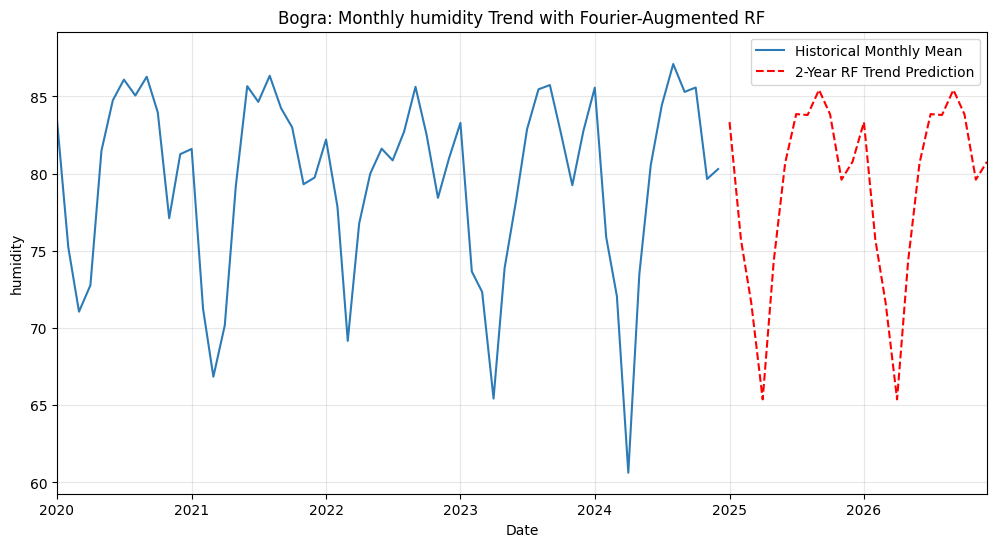

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb


# 1. Prepare Monthly Data
df = df_district.copy() # [cite: 101]
df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) # [cite: 116]
df_monthly_hum = df.set_index('date')['humidity'].resample('MS').mean().reset_index()

# 2. Engineering Fourier Features for Seasonality
# This replaces the need for interpolation/splines
def add_fourier_features(df, period=12, n_terms=3): # Monthly period is 12
    for n in range(1, n_terms + 1):
        # Using month index (1-12) as the base for the cycle
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly_hum.copy())
df_features['year_val'] = df_features['date'].dt.year

# 3. Define Features and Target
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]
FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['humidity']

# 4. Train Random Forest [cite: 145, 146]
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,         # Slowed down for stable trend learning
    max_depth=4,                # Restricted depth to prevent memorizing noise
    num_leaves=10,              # Low number of leaves is critical for small data
    min_child_samples=5,        # Minimum data points in a leaf (prevents tiny, specific branches)
    
    subsample=0.7,              # Stochastic bagging for robustness
    subsample_freq=1,
    colsample_bytree=0.7,       # Feature bagging
    
    reg_alpha=0.2,              # L1 regularization
    reg_lambda=0.2,             # L2 regularization
    
    importance_type='gain',     # More useful for understanding "Shape" than 'split'
    random_state=42,
    n_jobs=-1,
    verbosity=-1                # Suppress warnings about small dataset
)

lgb_model.fit(X_train, y_train)


# 5. Predict 2 Years Future (24 months)
last_date = df_features['date'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=24, freq='MS')
future_df = pd.DataFrame({'date': future_dates})
future_df['year_val'] = future_df['date'].dt.year
future_df = add_fourier_features(future_df)

predictions_hum = lgb_model.predict(future_df[FEATURES])


# 6. Visualization
plt.figure(figsize=(12, 6))
plt.plot(df_features['date'], y, label='Historical Monthly Mean', color='#2c7bb6') # [cite: 80]
plt.plot(future_dates, predictions_hum, label='2-Year RF Trend Prediction', linestyle='--', color='red')
plt.title('Bogra: Monthly humidity Trend with Fourier-Augmented RF')
plt.xlabel('Date')
plt.ylabel('humidity')
plt.legend()
plt.grid(True, alpha=0.3)
# Set the start date to Jan 1st, 2023
plt.xlim(pd.Timestamp('2020-01-01'), future_dates.max())
plt.show()

<>:20: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:24: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:20: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:24: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\User\AppData\Local\Temp\ipykernel_23688\2792750790.py:20: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  color='red', alpha=0.08, label='95% Prediction Interval ($\pm 1.96 \sigma$)')
C:\Users\User\AppData\Local\Temp\ipykernel_23688\2792750790.py:24: SyntaxWarning: "\p" is 

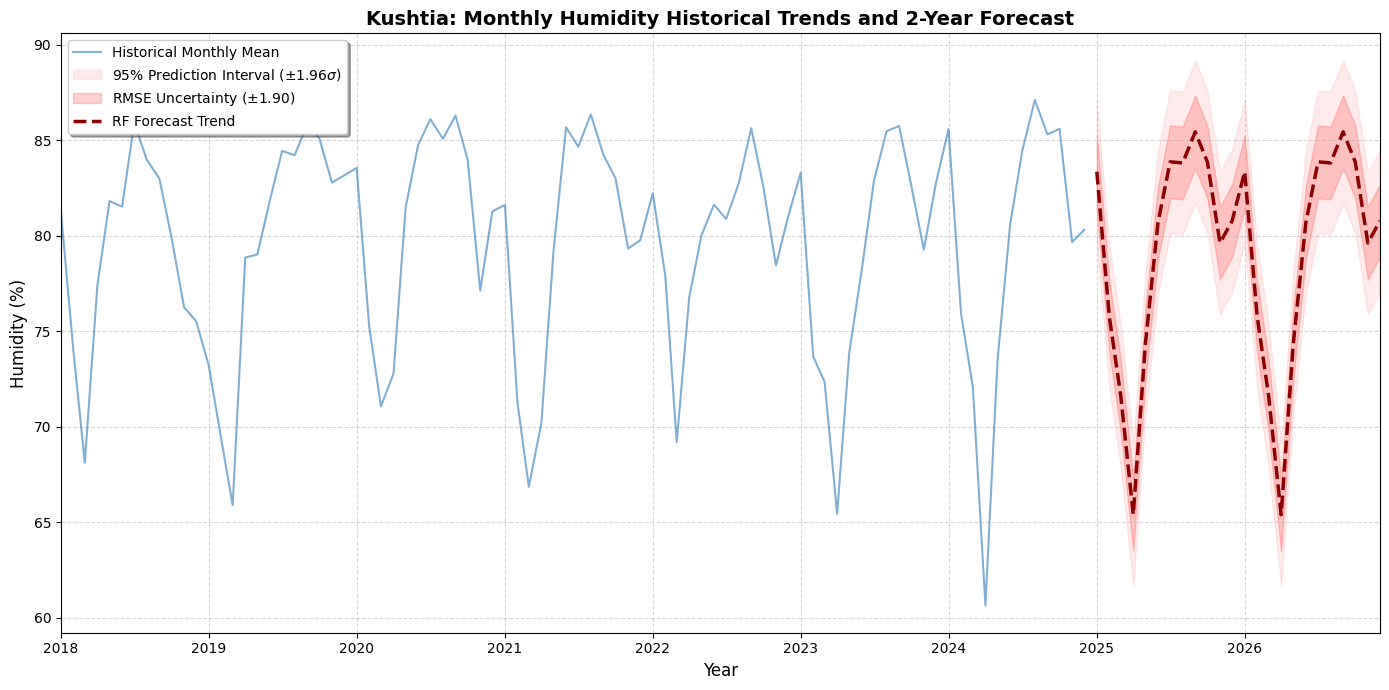

In [ ]:
# 5. Predict 2 Years Future with Empirical Validation
mean_preds = lgb_model.predict(future_df[FEATURES])

best_model_rmse = 2.4026 
upper_95 = mean_preds + (1.96 * best_model_rmse)
lower_95 = mean_preds - (1.96 * best_model_rmse)
upper_68 = mean_preds + best_model_rmse
lower_68 = mean_preds - best_model_rmse

# 2. Setup the Plot
plt.figure(figsize=(14, 7))

# 3. Plot Historical Data (The Context)
# Ensure df_features['date'] is in datetime format
plt.plot(df_features['date'], y, label='Historical Monthly Mean', 
         color='#2c7bb6', alpha=0.6, linewidth=1.5)

# 4. Plot the 95% Confidence Interval (The Outer Cloud)
plt.fill_between(future_dates, lower_95, upper_95, 
                 color='red', alpha=0.08, label='95% Prediction Interval ($\pm 1.96 \sigma$)')

# 5. Plot the 68% Confidence Interval (The RMSE Cloud)
plt.fill_between(future_dates, lower_68, upper_68, 
                 color='red', alpha=0.18, label=f'RMSE Uncertainty ($\pm${best_model_rmse:.2f})')

# 6. Plot the Future Prediction Mean (The Trend)
plt.plot(future_dates, mean_preds, label='RF Forecast Trend', 
         linestyle='--', color='darkred', lw=2.5)

# 7. Journal Formatting & Aesthetics
plt.title(f'{district}: Monthly Humidity Historical Trends and 2-Year Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Humidity (%)', fontsize=12)

# Set the x-axis to start slightly before the forecast for better perspective
# Adjust '2018-01-01' to whatever date makes your historical trend visible
plt.xlim(pd.Timestamp('2018-01-01'), future_dates.max()) 

plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

# Optional: Tight layout to prevent label clipping
plt.tight_layout()

plt.show()

In [ ]:
# create the dataframe of the predicted values of 2025 and 2026
df_predictions_humidity = pd.DataFrame({
    'date': future_dates,
    'predicted_humidity': predictions_hum
})


In [ ]:
df_predictions_humidity

,date,predicted_humidity
0,2025-01-01,84.851787
1,2025-02-01,76.474647
2,2025-03-01,73.247388
3,2025-04-01,74.097493
4,2025-05-01,79.081904
5,2025-06-01,85.485347
6,2025-07-01,84.148922
7,2025-08-01,84.843049
8,2025-09-01,86.101784
9,2025-10-01,85.434279


# temperature

In [ ]:
import pandas as pd

In [ ]:
df_district = pd.read_csv(f'../../../1980-2024-dataset/{district}_historical_weather_1980_2024.csv')

df_district = df_district.drop('district', axis =1 )

desired_colmn = ['day', 'month', 'year', 'temperature(degree C)']
df_district = df_district[desired_colmn]

df_district = df_district.dropna()

df_district.head()

,day,month,year,temperature(degree C)
0,1,1,1980,18.2
1,2,1,1980,16.9
2,3,1,1980,18.2
3,4,1,1980,17.4
4,5,1,1980,18.6


Date range: 2014-01-01 to 2024-12-31


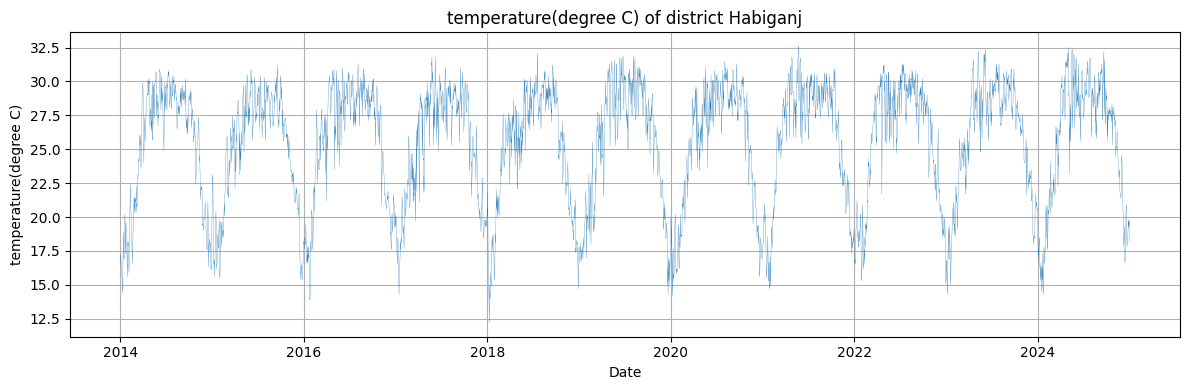

In [ ]:
import matplotlib.pyplot as plt

if 'date' not in df_district.columns:
    df_district['date'] = pd.to_datetime(df_district[['year', 'month', 'day']])

# # show date range
# min_date = df_district['date'].min()
# max_date = df_district['date'].max()
# print(f"Date range: {min_date.date()} to {max_date.date()}")


# 1980-2024 dile 92% R2 xgboost
# 2010-2024 dile 96.7% r2 rf
# 2014/2024 filr 95% r2 xgboost
# filter data for custom date range: 2020 to 2024
df_district = df_district[
    (df_district['date'] >= '2014-01-01') & (df_district['date'] <= '2024-12-31')
]
custom_range_df = df_district.copy()

# show date range
min_date = custom_range_df['date'].min()
max_date = custom_range_df['date'].max()
print(f"Date range: {min_date.date()} to {max_date.date()}")

# plot daily temperature time series
plt.figure(figsize=(12, 4))
plt.plot(df_district['date'], df_district['temperature(degree C)'], linewidth=0.2)
plt.xlabel('Date')
plt.ylabel('temperature(degree C)')
plt.title(f'temperature(degree C) of district {district}')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Prepare Monthly Data
df = df_district.copy() # [cite: 101]
df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) # [cite: 116]
df_monthly_temp = df.set_index('date')['temperature(degree C)'].resample('MS').mean().reset_index()
df_monthly_temp = df_monthly_temp.interpolate(method='linear').dropna() # Fill missing gaps using linear interpolation (common for weather data)

# 2. Engineering Fourier Features for Seasonality
# This replaces the need for interpolation/splines
def add_fourier_features(df, period=12, n_terms=3): # Monthly period is 12
    for n in range(1, n_terms + 1):
        # Using month index (1-12) as the base for the cycle
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly_temp.copy())
df_features['year_val'] = df_features['date'].dt.year

# 3. Define Features and Target
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score

FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['temperature(degree C)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True)


## RF temp

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6, 
    min_samples_split=2,
    min_samples_leaf=7,
    random_state=42,
    n_jobs=-1,
    max_features= 1.0
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

rf_r2_f  = r2_score(y_test, y_pred)
rf_mse_f = mean_squared_error(y_test, y_pred)
rf_rmse_f = np.sqrt(rf_mse_f)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

rf_acc_05 = tolerance_accuracy(y_test.values, y_pred, 0.5)
rf_acc_10 = tolerance_accuracy(y_test.values, y_pred, 1.0)
rf_acc_20 = tolerance_accuracy(y_test.values, y_pred, 2.0)
rf_acc_30 = tolerance_accuracy(y_test.values, y_pred, 3.0)

print("=== Random Forest + Fourier – Humidity Prediction (Test) ===")
print(f"R²          : {rf_r2_f:.4f}")
print(f"RMSE        : {rf_rmse_f:.3f} °C")
print(f"MSE         : {rf_mse_f:.4f}")
print("Accuracy (± tolerance):")
print(f"  ±0.5 °C : {rf_acc_05 * 100:5.2f}%")
print(f"  ±1.0 °C : {rf_acc_10 * 100:5.2f}%")
print(f"  ±2.0 °C : {rf_acc_20 * 100:5.2f}%")
print(f"  ±3.0 °C : {rf_acc_30 * 100:5.2f}%")

# ------------------------------------------------------------------
# 9. 5-fold CV (R²)
# ------------------------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)

# 2. Run cross-validation using the tscv object
rf_cv_r2 = cross_val_score(rf, X, y, cv=tscv, scoring='r2', n_jobs=-1)

print("\n=== TimeSeriesSplit CV R² (Seasonal Trend Validation) ===")
print(f"Mean R² : {rf_cv_r2.mean():.4f}  (±{rf_cv_r2.std():.4f})")
print(f"Scores  : {np.round(rf_cv_r2, 4)}")

fi = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))


=== Random Forest + Fourier – Humidity Prediction (Test) ===
R²          : 0.9301
RMSE        : 1.043 °C
MSE         : 1.0884
Accuracy (± tolerance):
  ±0.5 °C : 29.63%
  ±1.0 °C : 66.67%
  ±2.0 °C : 96.30%
  ±3.0 °C : 100.00%

=== TimeSeriesSplit CV R² (Seasonal Trend Validation) ===
Mean R² : 0.7814  (±0.1615)
Scores  : [0.4801 0.765  0.8255 0.9128 0.9234]

=== Feature Importances (Top 10) ===
 feature  importance
   cos_1    0.734014
   sin_2    0.102582
   sin_1    0.101912
   sin_3    0.026720
   cos_3    0.014911
   cos_2    0.013115
year_val    0.006747


## XGBoost temp

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor

xgb_model = xgb.XGBRegressor( 
    n_estimators=1000,          # Increased, but we will rely on a low learning rate
    learning_rate=0.01,         # Much lower to "crawl" toward the seasonal shape
    max_depth=4,                # Shallower trees prevent the model from memorizing specific years
    
    # --- Regularization to handle small N=132 ---
    reg_alpha=0.1,              # L1 regularization to keep feature weights stable
    reg_lambda=1.0,             # L2 regularization to prevent extreme predictions
    subsample=0.8,              # Use 80% of data per tree to add robustness
    colsample_bytree=0.8,       # Randomly select features to reduce dominance of sin_1
    
    # --- Optimization ---
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = xgb_model.predict(X_test)

xgboost_r2_f  = r2_score(y_test, y_pred)            # averaged R^2 for multioutput
xgboost_mse_f = mean_squared_error(y_test, y_pred)  # averaged MSE
xgboost_rmse_f = np.sqrt(xgboost_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    # returns fraction (0..1) of predictions within tol across all targets
    return ((np.abs(y_true - y_hat) <= tol).mean())

xgboost_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
xgboost_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
xgboost_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
xgboost_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== XGBoost Regression Metrics (Test) ====")
print(f"xgboost_R^2  : {xgboost_r2_f:.4f}")
print(f"xgboost_MSE  : {xgboost_mse_f:.4f}")
print(f"xgboost_RMSE : {xgboost_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {xgboost_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {xgboost_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {xgboost_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {xgboost_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)

xgb_cv_r2 = cross_val_score(xgb_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean xgboost_R^2 : {xgb_cv_r2.mean():.4f}  |  Std : {xgb_cv_r2.std():.4f}")

# --- 7) Feature importances (average across outputs) ---
# MultiOutputRegressor stores estimators_ after fit


fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.head(10).to_string(index=False))

==== XGBoost Regression Metrics (Test) ====
xgboost_R^2  : 0.9534
xgboost_MSE  : 0.7256
xgboost_RMSE : 0.8518
Accuracy (|error| ≤ tolerance):
  ±0.5°C : 44.44%
  ±1.0°C : 77.78%
  ±2.0°C : 100.00%
  ±3.0°C : 100.00%

==== 5-Fold CV R^2 ====
Mean xgboost_R^2 : 0.9512  |  Std : 0.0109

==== Top Feature Importances ====
 feature  importance
   cos_1    0.501351
   sin_2    0.190114
   sin_1    0.139750
   sin_3    0.091365
   cos_3    0.042757
   cos_2    0.027791
year_val    0.006872


## light gbm temp

In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor


# --- 4) Train MultiOutput LightGBM ---
import lightgbm as lgb

# Optimized for Seasonal Shape extraction on N=132
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,         # Slowed down for stable trend learning
    max_depth=4,                # Restricted depth to prevent memorizing noise
    num_leaves=10,              # Low number of leaves is critical for small data
    min_child_samples=5,        # Minimum data points in a leaf (prevents tiny, specific branches)
    
    subsample=0.7,              # Stochastic bagging for robustness
    subsample_freq=1,
    colsample_bytree=0.7,       # Feature bagging
    
    reg_alpha=0.2,              # L1 regularization
    reg_lambda=0.2,             # L2 regularization
    
    importance_type='gain',     # More useful for understanding "Shape" than 'split'
    random_state=42,
    n_jobs=-1,
    verbosity=-1                # Suppress warnings about small dataset
)

lgb_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = lgb_model.predict(X_test)

lgb_r2_f  = r2_score(y_test, y_pred)
lgb_mse_f = mean_squared_error(y_test, y_pred)
lgb_rmse_f = np.sqrt(lgb_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    return ((np.abs(y_true - y_hat) <= tol).mean())

lgb_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
lgb_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
lgb_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
lgb_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== LightGBM Regression Metrics (Test) ====")
print(f"LGB_R^2  : {lgb_r2_f:.4f}")
print(f"LGB_MSE  : {lgb_mse_f:.4f}")
print(f"LGB_RMSE : {lgb_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {lgb_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {lgb_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {lgb_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {lgb_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)
lgb_cv_r2 = cross_val_score(lgb_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean LGB_R^2 : {lgb_cv_r2.mean():.4f}  |  Std : {lgb_cv_r2.std():.4f}")



fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.to_string(index=False))


==== LightGBM Regression Metrics (Test) ====
LGB_R^2  : 0.9516
LGB_MSE  : 0.7539
LGB_RMSE : 0.8683
Accuracy (|error| ≤ tolerance):
  ±0.5°C : 37.04%
  ±1.0°C : 85.19%
  ±2.0°C : 100.00%
  ±3.0°C : 100.00%

==== 5-Fold CV R^2 ====
Mean LGB_R^2 : 0.9553  |  Std : 0.0134

==== Top Feature Importances ====
 feature   importance
   cos_1 29651.901873
   sin_1 12026.498060
   sin_2  8464.864267
   sin_3  4033.746916
   cos_2  3976.009417
year_val  1381.917688
   cos_3  1006.800647


## cat boost temp

In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
from catboost import CatBoostRegressor

# --- 4) Train MultiOutput LightGBM ---
cat_model = CatBoostRegressor(
    iterations=1500,           # Increased iterations with a lower learning rate
    learning_rate=0.01,        # "Crawl" toward the seasonal trend
    depth=4,                   # Shallower trees for better generalization on small N=132
    l2_leaf_reg=10,            # Higher L2 regularization to smooth the seasonal curve
    
    bootstrap_type='Bayesian',
    bagging_temperature=0.5,   # Reduced slightly for more stable bagging
    random_strength=2,         # Adds randomness to scoring splits, preventing overfitting
    
    loss_function='RMSE',      # Standard for regression; 'Huber' is also an option if data is noisy
    od_type='Iter',            # Overfitting detector
    od_wait=50,                # Stop early if the trend isn't improving
    
    random_seed=42,
    verbose=0
)


cat_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = cat_model.predict(X_test)

cat_r2_f  = r2_score(y_test, y_pred)
cat_mse_f = mean_squared_error(y_test, y_pred)
cat_rmse_f = np.sqrt(cat_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    return ((np.abs(y_true - y_hat) <= tol).mean())

cat_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
cat_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
cat_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
cat_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== CatBoost Regression Metrics (Test) ====")
print(f"CatBoost_R^2  : {cat_r2_f:.4f}")
print(f"CatBoost_MSE  : {cat_mse_f:.4f}")
print(f"CatBoost_RMSE : {cat_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {cat_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {cat_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {cat_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {cat_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)
cat_cv_r2 = cross_val_score(cat_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean CAT_R^2 : {cat_cv_r2.mean():.4f}  |  Std : {cat_cv_r2.std():.4f}")

# --- 7) Feature importances (average across outputs) ---

fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": cat_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.to_string(index=False))


==== CatBoost Regression Metrics (Test) ====
CatBoost_R^2  : 0.9504
CatBoost_MSE  : 0.7726
CatBoost_RMSE : 0.8790
Accuracy (|error| ≤ tolerance):
  ±0.5°C : 33.33%
  ±1.0°C : 81.48%
  ±2.0°C : 100.00%
  ±3.0°C : 100.00%

==== 5-Fold CV R^2 ====
Mean CAT_R^2 : 0.9500  |  Std : 0.0191

==== Top Feature Importances ====
 feature  importance
   cos_1   59.293745
   sin_1   14.633168
   sin_2   10.380288
   sin_3    6.208030
   cos_2    3.730750
   cos_3    3.389300
year_val    2.364719


## comparision temp

In [ ]:
# show the comparision of all the models in a table.based on R^2, MSE, RMSE, and accuracy within tolerances.
# Summary of model performance
model_performance = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM", "CatBoost"],
    "R^2": [rf_r2_f, xgboost_r2_f, lgb_r2_f, cat_r2_f],  # Replace with actual R^2 values from each model
    "CV R2": [rf_cv_r2.mean(), xgb_cv_r2.mean(), lgb_cv_r2.mean(), cat_cv_r2.mean()],
    "MSE": [rf_mse_f, xgboost_mse_f, lgb_mse_f, cat_mse_f],  # Replace with actual MSE values from each model
    "RMSE": [rf_rmse_f, xgboost_rmse_f, lgb_rmse_f, cat_rmse_f],  # Replace with actual RMSE values from each model
    "Acc ±0.5°C (%)": [rf_acc_05*100, xgboost_acc_05*100, lgb_acc_05*100, cat_acc_05*100],  # Replace with actual accuracy values
    "Acc ±1.0°C (%)": [rf_acc_10*100, xgboost_acc_10*100, lgb_acc_10*100, cat_acc_10*100],
    "Acc ±2.0°C (%)": [rf_acc_20*100, xgboost_acc_20*100, lgb_acc_20*100, cat_acc_20*100],
    "Acc ±3.0°C (%)": [rf_acc_30*100, xgboost_acc_30*100, lgb_acc_30*100, cat_acc_30*100],
})
print("\n==== Model Performance Comparison ====")
print(model_performance.to_string(index=False))



==== Model Performance Comparison ====
        Model      R^2    CV R2      MSE     RMSE  Acc ±0.5°C (%)  Acc ±1.0°C (%)  Acc ±2.0°C (%)  Acc ±3.0°C (%)
Random Forest 0.930062 0.781354 1.088420 1.043274       29.629630       66.666667       96.296296           100.0
      XGBoost 0.953373 0.951192 0.725635 0.851842       44.444444       77.777778      100.000000           100.0
     LightGBM 0.951557 0.955342 0.753892 0.868269       37.037037       85.185185      100.000000           100.0
     CatBoost 0.950356 0.950007 0.772593 0.878973       33.333333       81.481481      100.000000           100.0


In [ ]:
# Simple Additive Weighting

def select_best_model_journal(df):
    """
    Journal-quality model selection using weighted scoring 
    and Overfitting Analysis.
    """
    # 1. Calculate Generalization Gap (Lower is better)
    # Measures the difference between training-like (CV) and testing performance
    df['Gen_Gap'] = abs(df['R^2'] - df['CV R2'])
    
    # 2. Define Metric Polarities (True = Maximize, False = Minimize)
    metrics = {
        'R^2': True, 
        'CV R2': True, 
        'RMSE': False, 
        'Gen_Gap': False, 
        'Acc ±1.0°C (%)': True
    }
    
    # 3. Min-Max Normalization to bring all metrics to 0-1 range
    # This ensures RMSE (2.5) doesn't outweigh R^2 (0.75) simply by scale
    df_norm = df.copy()
    for metric, maximize in metrics.items():
        min_val = df[metric].min()
        max_val = df[metric].max()
        if maximize:
            df_norm[metric] = (df[metric] - min_val) / (max_val - min_val)
        else:
            df_norm[metric] = (max_val - df[metric]) / (max_val - min_val)
            
    # 4. Compute Weighted Composite Score (WCS)
    # Weights can be adjusted based on the specific importance for the study
    weights = {'R^2': 0.25, 'CV R2': 0.25, 'RMSE': 0.20, 'Gen_Gap': 0.20, 'Acc ±1.0°C (%)': 0.10}
    df['Composite_Score'] = sum(df_norm[m] * weights[m] for m in weights)
    
    # 5. Rank and Flag Overfitting
    df['Status'] = np.where(df['Gen_Gap'] > 0.1, 'Overfit Risk', 'Robust')
    
    return df.sort_values('Composite_Score', ascending=False)

# Execute
journal_results = select_best_model_journal(model_performance)
print(journal_results[['Model', 'R^2', 'CV R2', 'Gen_Gap', 'Composite_Score', 'Status']])

           Model       R^2     CV R2   Gen_Gap  Composite_Score        Status
2       LightGBM  0.951557  0.955342  0.003785         0.958734        Robust
1        XGBoost  0.953373  0.951192  0.002181         0.951566        Robust
3       CatBoost  0.950356  0.950007  0.000349         0.911630        Robust
0  Random Forest  0.930062  0.781354  0.148708         0.000000  Overfit Risk


## predicting with best model for two years temperature

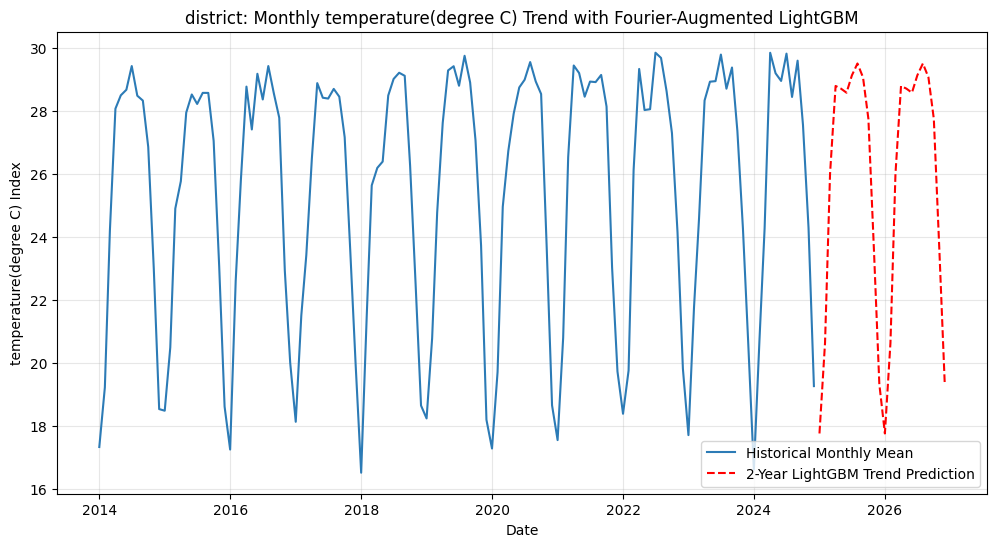

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


# 1. Prepare Monthly Data
df = df_district.copy() # [cite: 101]
df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) # [cite: 116]
df_monthly = df.set_index('date')['temperature(degree C)'].resample('MS').mean().reset_index()

# 2. Engineering Fourier Features for Seasonality
# This replaces the need for interpolation/splines
def add_fourier_features(df, period=12, n_terms=3): # Monthly period is 12
    for n in range(1, n_terms + 1):
        # Using month index (1-12) as the base for the cycle
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly.copy())
df_features['year_val'] = df_features['date'].dt.year

# 3. Define Features and Target
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]
FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['temperature(degree C)']

# 4. Train Random Forest [cite: 145, 146]
lgb_model = lgb.LGBMRegressor(
     n_estimators=1000,
    learning_rate=0.01,         # Slowed down for stable trend learning
    max_depth=4,                # Restricted depth to prevent memorizing noise
    num_leaves=10,              # Low number of leaves is critical for small data
    min_child_samples=5,        # Minimum data points in a leaf (prevents tiny, specific branches)
    
    subsample=0.7,              # Stochastic bagging for robustness
    subsample_freq=1,
    colsample_bytree=0.7,       # Feature bagging
    
    reg_alpha=0.2,              # L1 regularization
    reg_lambda=0.2,             # L2 regularization
    
    importance_type='gain',     # More useful for understanding "Shape" than 'split'
    random_state=42,
    n_jobs=-1,
    verbosity=-1                # Suppress warnings about small dataset

)
lgb_model.fit(X_train, y_train)

# 5. Predict 2 Years Future (24 months)
last_date = df_features['date'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=24, freq='MS')
future_df = pd.DataFrame({'date': future_dates})
future_df['year_val'] = future_df['date'].dt.year
future_df = add_fourier_features(future_df)

predictions_temp = lgb_model.predict(future_df[FEATURES])

# 6. Visualization
plt.figure(figsize=(12, 6))
plt.plot(df_features['date'], y, label='Historical Monthly Mean', color='#2c7bb6') # [cite: 80]
plt.plot(future_dates, predictions_temp, label='2-Year LightGBM Trend Prediction', linestyle='--', color='red')
plt.title('district: Monthly temperature(degree C) Trend with Fourier-Augmented LightGBM')
plt.xlabel('Date')
plt.ylabel('temperature(degree C) Index')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\p'
<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:21: SyntaxWarning: invalid escape sequence '\p'
<>:25: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Khalid\AppData\Local\Temp\ipykernel_21580\1607163110.py:21: SyntaxWarning: invalid escape sequence '\p'
  color='red', alpha=0.08, label='95% Prediction Interval ($\pm 1.96 \sigma$)')
C:\Users\Khalid\AppData\Local\Temp\ipykernel_21580\1607163110.py:25: SyntaxWarning: invalid escape sequence '\p'
  color='red', alpha=0.18, label=f'RMSE Uncertainty ($\pm${best_model_rmse:.2f})')


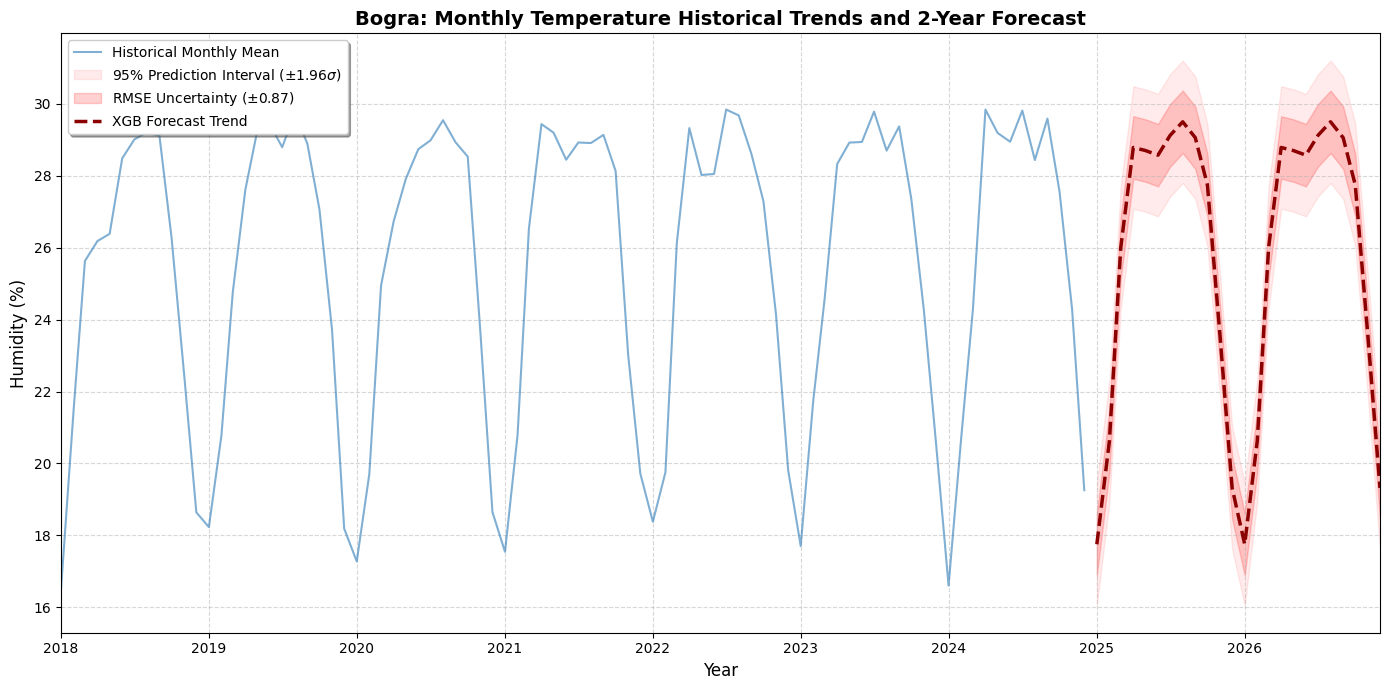

In [ ]:
# 5. Predict 2 Years Future with Empirical Validation
mean_preds = lgb_model.predict(future_df[FEATURES])

# 1. Define the Uncertainty Bounds (Based on your LGB RMSE)
best_model_rmse = 0.8683 
upper_95 = mean_preds + (1.96 * best_model_rmse)
lower_95 = mean_preds - (1.96 * best_model_rmse)
upper_68 = mean_preds + best_model_rmse
lower_68 = mean_preds - best_model_rmse

# 2. Setup the Plot
plt.figure(figsize=(14, 7))

# 3. Plot Historical Data (The Context)
# Ensure df_features['date'] is in datetime format
plt.plot(df_features['date'], y, label='Historical Monthly Mean', 
         color='#2c7bb6', alpha=0.6, linewidth=1.5)

# 4. Plot the 95% Confidence Interval (The Outer Cloud)
plt.fill_between(future_dates, lower_95, upper_95, 
                 color='red', alpha=0.08, label='95% Prediction Interval ($\pm 1.96 \sigma$)')

# 5. Plot the 68% Confidence Interval (The RMSE Cloud)
plt.fill_between(future_dates, lower_68, upper_68, 
                 color='red', alpha=0.18, label=f'RMSE Uncertainty ($\pm${best_model_rmse:.2f})')

# 6. Plot the Future Prediction Mean (The Trend)
plt.plot(future_dates, mean_preds, label='XGB Forecast Trend', 
         linestyle='--', color='darkred', lw=2.5)

# 7. Journal Formatting & Aesthetics
plt.title('Bogra: Monthly Temperature Historical Trends and 2-Year Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Humidity (%)', fontsize=12)

# Set the x-axis to start slightly before the forecast for better perspective
# Adjust '2018-01-01' to whatever date makes your historical trend visible
plt.xlim(pd.Timestamp('2018-01-01'), future_dates.max()) 

plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

# Optional: Tight layout to prevent label clipping
plt.tight_layout()

plt.show()

In [ ]:
df_predictions_temp = pd.DataFrame({
    'date': future_dates,
    'predicted_temp': predictions_temp
})

df_predictions_temp

,date,predicted_temp
0,2025-01-01,17.755384
1,2025-02-01,20.626574
2,2025-03-01,25.995973
3,2025-04-01,28.783582
4,2025-05-01,28.698726
5,2025-06-01,28.569975
6,2025-07-01,29.121091
7,2025-08-01,29.497105
8,2025-09-01,29.056182
9,2025-10-01,27.739745


# Solar radiation

In [ ]:
import pandas as pd

In [ ]:
df_district = pd.read_csv(f'../../../1980-2024-dataset/{district}_historical_weather_1980_2024.csv')

df_district = df_district.drop('district', axis =1 )

desired_colmn = ['day', 'month', 'year', 'solar_radiation']
df_district = df_district[desired_colmn]

df_district = df_district.dropna()

df_district.head()

,day,month,year,solar_radiation
12054,1,1,2013,170.3
12055,2,1,2013,174.5
12056,3,1,2013,105.4
12057,4,1,2013,169.6
12058,5,1,2013,179.2


Date range: 2014-01-01 to 2024-12-31


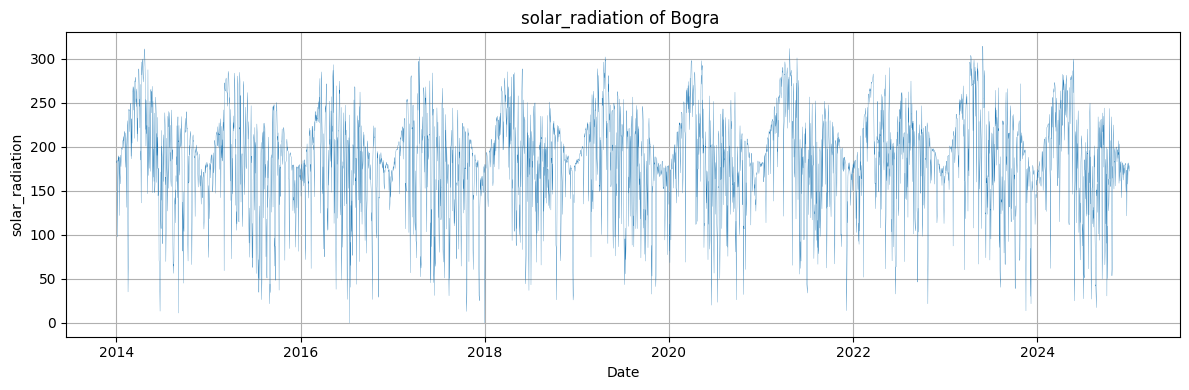

In [ ]:
import matplotlib.pyplot as plt

if 'date' not in df_district.columns:
    df_district['date'] = pd.to_datetime(df_district[['year', 'month', 'day']])

# # show date range
# min_date = df_district['date'].min()
# max_date = df_district['date'].max()
# print(f"Date range: {min_date.date()} to {max_date.date()}")

# 2010-2024 dile 83% r2 lightgbm
# 2014- 2024 dile 82% R2
# 2018-2024 dile 52% R2 xgboost

# filter data for custom date range: 2020 to 2024
df_district = df_district[
    (df_district['date'] >= '2014-01-01') & (df_district['date'] <= '2024-12-31')
]
custom_range_df = df_district.copy()

# show date range
min_date = custom_range_df['date'].min()
max_date = custom_range_df['date'].max()
print(f"Date range: {min_date.date()} to {max_date.date()}")

# plot daily temperature time series
plt.figure(figsize=(12, 4))
plt.plot(df_district['date'], df_district['solar_radiation'], linewidth=0.2)
plt.xlabel('Date')
plt.ylabel('solar_radiation')
plt.title('solar_radiation of Bogra ')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Prepare Monthly Data
df = df_district.copy() # [cite: 101]
df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) # [cite: 116]
df_monthly_hum = df.set_index('date')['solar_radiation'].resample('MS').mean().reset_index()
df_monthly_hum = df_monthly_hum.dropna()

# 2. Engineering Fourier Features for Seasonality
# This replaces the need for interpolation/splines
def add_fourier_features(df, period=12, n_terms=3): # Monthly period is 12
    for n in range(1, n_terms + 1):
        # Using month index (1-12) as the base for the cycle
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly_hum.copy())
df_features['year_val'] = df_features['date'].dt.year

# 3. Define Features and Target
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score

FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['solar_radiation']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True)


## RF

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6, 
    min_samples_split=2,
    min_samples_leaf=7,
    random_state=42,
    n_jobs=-1,
    max_features= 1.0
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

rf_r2_f  = r2_score(y_test, y_pred)
rf_mse_f = mean_squared_error(y_test, y_pred)
rf_rmse_f = np.sqrt(rf_mse_f)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

rf_acc_05 = tolerance_accuracy(y_test.values, y_pred, 0.5)
rf_acc_10 = tolerance_accuracy(y_test.values, y_pred, 1.0)
rf_acc_20 = tolerance_accuracy(y_test.values, y_pred, 2.0)
rf_acc_30 = tolerance_accuracy(y_test.values, y_pred, 3.0)

print("=== Random Forest + Fourier – Humidity Prediction (Test) ===")
print(f"R²          : {rf_r2_f:.4f}")
print(f"RMSE        : {rf_rmse_f:.3f} °C")
print(f"MSE         : {rf_mse_f:.4f}")
print("Accuracy (± tolerance):")
print(f"  ±0.5 °C : {rf_acc_05 * 100:5.2f}%")
print(f"  ±1.0 °C : {rf_acc_10 * 100:5.2f}%")
print(f"  ±2.0 °C : {rf_acc_20 * 100:5.2f}%")
print(f"  ±3.0 °C : {rf_acc_30 * 100:5.2f}%")

# ------------------------------------------------------------------
# 9. 5-fold CV (R²)
# ------------------------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)

# 2. Run cross-validation using the tscv object
rf_cv_r2 = cross_val_score(rf, X, y, cv=tscv, scoring='r2', n_jobs=-1)

print("\n=== TimeSeriesSplit CV R² (Seasonal Trend Validation) ===")
print(f"Mean R² : {rf_cv_r2.mean():.4f}  (±{rf_cv_r2.std():.4f})")
print(f"Scores  : {np.round(rf_cv_r2, 4)}")

fi = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))


=== Random Forest + Fourier – Humidity Prediction (Test) ===
R²          : 0.5260
RMSE        : 19.163 °C
MSE         : 367.2086
Accuracy (± tolerance):
  ±0.5 °C :  0.00%
  ±1.0 °C :  0.00%
  ±2.0 °C :  3.70%
  ±3.0 °C :  7.41%

=== TimeSeriesSplit CV R² (Seasonal Trend Validation) ===
Mean R² : 0.5306  (±0.1331)
Scores  : [0.3325 0.5873 0.6935 0.4215 0.618 ]

=== Feature Importances (Top 10) ===
 feature  importance
   sin_1    0.825316
year_val    0.043964
   sin_3    0.037875
   sin_2    0.034061
   cos_1    0.024249
   cos_3    0.022191
   cos_2    0.012345


## XGB

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor

xgb_model = xgb.XGBRegressor( 
    n_estimators=1000,          # Increased, but we will rely on a low learning rate
    learning_rate=0.01,         # Much lower to "crawl" toward the seasonal shape
    max_depth=4,                # Shallower trees prevent the model from memorizing specific years
    
    # --- Regularization to handle small N=132 ---
    reg_alpha=0.1,              # L1 regularization to keep feature weights stable
    reg_lambda=1.0,             # L2 regularization to prevent extreme predictions
    subsample=0.8,              # Use 80% of data per tree to add robustness
    colsample_bytree=0.8,       # Randomly select features to reduce dominance of sin_1
    
    # --- Optimization ---
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = xgb_model.predict(X_test)

xgboost_r2_f  = r2_score(y_test, y_pred)            # averaged R^2 for multioutput
xgboost_mse_f = mean_squared_error(y_test, y_pred)  # averaged MSE
xgboost_rmse_f = np.sqrt(xgboost_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    # returns fraction (0..1) of predictions within tol across all targets
    return ((np.abs(y_true - y_hat) <= tol).mean())

xgboost_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
xgboost_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
xgboost_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
xgboost_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== XGBoost Regression Metrics (Test) ====")
print(f"xgboost_R^2  : {xgboost_r2_f:.4f}")
print(f"xgboost_MSE  : {xgboost_mse_f:.4f}")
print(f"xgboost_RMSE : {xgboost_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {xgboost_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {xgboost_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {xgboost_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {xgboost_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)

xgb_cv_r2 = cross_val_score(xgb_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean xgboost_R^2 : {xgb_cv_r2.mean():.4f}  |  Std : {xgb_cv_r2.std():.4f}")

# --- 7) Feature importances (average across outputs) ---
# MultiOutputRegressor stores estimators_ after fit


fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.head(10).to_string(index=False))

==== XGBoost Regression Metrics (Test) ====
xgboost_R^2  : 0.6608
xgboost_MSE  : 262.8240
xgboost_RMSE : 16.2118
Accuracy (|error| ≤ tolerance):
  ±0.5°C :  0.00%
  ±1.0°C :  3.70%
  ±2.0°C :  7.41%
  ±3.0°C : 11.11%

==== 5-Fold CV R^2 ====
Mean xgboost_R^2 : 0.3569  |  Std : 0.1684

==== Top Feature Importances ====
 feature  importance
   sin_1    0.297391
   cos_2    0.238681
   sin_2    0.134613
   sin_3    0.115341
   cos_1    0.098545
   cos_3    0.062711
year_val    0.052720


## light gbm

In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor


# --- 4) Train MultiOutput LightGBM ---
import lightgbm as lgb

# Optimized for Seasonal Shape extraction on N=132
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,         # Slowed down for stable trend learning
    max_depth=4,                # Restricted depth to prevent memorizing noise
    num_leaves=10,              # Low number of leaves is critical for small data
    min_child_samples=5,        # Minimum data points in a leaf (prevents tiny, specific branches)
    
    subsample=0.7,              # Stochastic bagging for robustness
    subsample_freq=1,
    colsample_bytree=0.7,       # Feature bagging
    
    reg_alpha=0.2,              # L1 regularization
    reg_lambda=0.2,             # L2 regularization
    
    importance_type='gain',     # More useful for understanding "Shape" than 'split'
    random_state=42,
    n_jobs=-1,
    verbosity=-1                # Suppress warnings about small dataset
)

lgb_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = lgb_model.predict(X_test)

lgb_r2_f  = r2_score(y_test, y_pred)
lgb_mse_f = mean_squared_error(y_test, y_pred)
lgb_rmse_f = np.sqrt(lgb_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    return ((np.abs(y_true - y_hat) <= tol).mean())

lgb_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
lgb_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
lgb_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
lgb_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== LightGBM Regression Metrics (Test) ====")
print(f"LGB_R^2  : {lgb_r2_f:.4f}")
print(f"LGB_MSE  : {lgb_mse_f:.4f}")
print(f"LGB_RMSE : {lgb_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {lgb_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {lgb_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {lgb_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {lgb_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)
lgb_cv_r2 = cross_val_score(lgb_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean LGB_R^2 : {lgb_cv_r2.mean():.4f}  |  Std : {lgb_cv_r2.std():.4f}")



fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.to_string(index=False))


==== LightGBM Regression Metrics (Test) ====
LGB_R^2  : 0.6239
LGB_MSE  : 291.3733
LGB_RMSE : 17.0697
Accuracy (|error| ≤ tolerance):
  ±0.5°C :  3.70%
  ±1.0°C :  3.70%
  ±2.0°C : 11.11%
  ±3.0°C : 18.52%

==== 5-Fold CV R^2 ====
Mean LGB_R^2 : 0.4923  |  Std : 0.1773

==== Top Feature Importances ====
 feature   importance
   sin_1 1.510098e+06
year_val 6.413348e+05
   cos_2 3.833676e+05
   cos_1 3.332868e+05
   sin_2 2.665322e+05
   sin_3 2.310433e+05
   cos_3 1.821887e+05


## cat

In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
from catboost import CatBoostRegressor

# --- 4) Train MultiOutput LightGBM ---
cat_model = CatBoostRegressor(
    iterations=1500,           # Increased iterations with a lower learning rate
    learning_rate=0.01,        # "Crawl" toward the seasonal trend
    depth=4,                   # Shallower trees for better generalization on small N=132
    l2_leaf_reg=10,            # Higher L2 regularization to smooth the seasonal curve
    
    bootstrap_type='Bayesian',
    bagging_temperature=0.5,   # Reduced slightly for more stable bagging
    random_strength=2,         # Adds randomness to scoring splits, preventing overfitting
    
    loss_function='RMSE',      # Standard for regression; 'Huber' is also an option if data is noisy
    od_type='Iter',            # Overfitting detector
    od_wait=50,                # Stop early if the trend isn't improving
    
    random_seed=42,
    verbose=0
)


cat_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = cat_model.predict(X_test)

cat_r2_f  = r2_score(y_test, y_pred)
cat_mse_f = mean_squared_error(y_test, y_pred)
cat_rmse_f = np.sqrt(cat_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    return ((np.abs(y_true - y_hat) <= tol).mean())

cat_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
cat_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
cat_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
cat_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== CatBoost Regression Metrics (Test) ====")
print(f"CatBoost_R^2  : {cat_r2_f:.4f}")
print(f"CatBoost_MSE  : {cat_mse_f:.4f}")
print(f"CatBoost_RMSE : {cat_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {cat_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {cat_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {cat_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {cat_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)
cat_cv_r2 = cross_val_score(cat_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean CAT_R^2 : {cat_cv_r2.mean():.4f}  |  Std : {cat_cv_r2.std():.4f}")

# --- 7) Feature importances (average across outputs) ---

fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": cat_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.to_string(index=False))


==== CatBoost Regression Metrics (Test) ====
CatBoost_R^2  : 0.6389
CatBoost_MSE  : 279.7933
CatBoost_RMSE : 16.7270
Accuracy (|error| ≤ tolerance):
  ±0.5°C :  0.00%
  ±1.0°C :  0.00%
  ±2.0°C : 11.11%
  ±3.0°C : 18.52%

==== 5-Fold CV R^2 ====
Mean CAT_R^2 : 0.5063  |  Std : 0.1091

==== Top Feature Importances ====
 feature  importance
   sin_1   44.730160
year_val   14.219149
   cos_2   11.044774
   sin_2    9.072666
   sin_3    8.943431
   cos_1    6.448896
   cos_3    5.540924


## comparision solar radiation

In [ ]:
# show the comparision of all the models in a table.based on R^2, MSE, RMSE, and accuracy within tolerances.
# Summary of model performance
model_performance = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM", "CatBoost"],
    "R^2": [rf_r2_f, xgboost_r2_f, lgb_r2_f, cat_r2_f],  # Replace with actual R^2 values from each model
    "CV R2": [rf_cv_r2.mean(), xgb_cv_r2.mean(), lgb_cv_r2.mean(), cat_cv_r2.mean()],
    "MSE": [rf_mse_f, xgboost_mse_f, lgb_mse_f, cat_mse_f],  # Replace with actual MSE values from each model
    "RMSE": [rf_rmse_f, xgboost_rmse_f, lgb_rmse_f, cat_rmse_f],  # Replace with actual RMSE values from each model
    "Acc ±0.5°C (%)": [rf_acc_05*100, xgboost_acc_05*100, lgb_acc_05*100, cat_acc_05*100],  # Replace with actual accuracy values
    "Acc ±1.0°C (%)": [rf_acc_10*100, xgboost_acc_10*100, lgb_acc_10*100, cat_acc_10*100],
    "Acc ±2.0°C (%)": [rf_acc_20*100, xgboost_acc_20*100, lgb_acc_20*100, cat_acc_20*100],
    "Acc ±3.0°C (%)": [rf_acc_30*100, xgboost_acc_30*100, lgb_acc_30*100, cat_acc_30*100],
})
print("\n==== Model Performance Comparison ====")
print(model_performance.to_string(index=False))



==== Model Performance Comparison ====
        Model      R^2    CV R2        MSE      RMSE  Acc ±0.5°C (%)  Acc ±1.0°C (%)  Acc ±2.0°C (%)  Acc ±3.0°C (%)
Random Forest 0.526043 0.530592 367.208611 19.162688        0.000000        0.000000        3.703704        7.407407
      XGBoost 0.660773 0.356930 262.824019 16.211848        0.000000        3.703704        7.407407       11.111111
     LightGBM 0.623924 0.492299 291.373326 17.069661        3.703704        3.703704       11.111111       18.518519
     CatBoost 0.638870 0.506287 279.793322 16.727024        0.000000        0.000000       11.111111       18.518519


In [ ]:
# Simple Additive Weighting

def select_best_model_journal(df):
    """
    Journal-quality model selection using weighted scoring 
    and Overfitting Analysis.
    """
    # 1. Calculate Generalization Gap (Lower is better)
    # Measures the difference between training-like (CV) and testing performance
    df['Gen_Gap'] = abs(df['R^2'] - df['CV R2'])
    
    # 2. Define Metric Polarities (True = Maximize, False = Minimize)
    metrics = {
        'R^2': True, 
        'CV R2': True, 
        'RMSE': False, 
        'Gen_Gap': False, 
        'Acc ±1.0°C (%)': True
    }
    
    # 3. Min-Max Normalization to bring all metrics to 0-1 range
    # This ensures RMSE (2.5) doesn't outweigh R^2 (0.75) simply by scale
    df_norm = df.copy()
    for metric, maximize in metrics.items():
        min_val = df[metric].min()
        max_val = df[metric].max()
        if maximize:
            df_norm[metric] = (df[metric] - min_val) / (max_val - min_val)
        else:
            df_norm[metric] = (max_val - df[metric]) / (max_val - min_val)
            
    # 4. Compute Weighted Composite Score (WCS)
    # Weights can be adjusted based on the specific importance for the study
    weights = {'R^2': 0.25, 'CV R2': 0.25, 'RMSE': 0.20, 'Gen_Gap': 0.20, 'Acc ±1.0°C (%)': 0.10}
    df['Composite_Score'] = sum(df_norm[m] * weights[m] for m in weights)
    
    # 5. Rank and Flag Overfitting
    df['Status'] = np.where(df['Gen_Gap'] > 0.1, 'Overfit Risk', 'Robust')
    
    return df.sort_values('Composite_Score', ascending=False)

# Execute
journal_results = select_best_model_journal(model_performance)
print(journal_results[['Model', 'R^2', 'CV R2', 'Gen_Gap', 'Composite_Score', 'Status']])

           Model       R^2     CV R2   Gen_Gap  Composite_Score        Status
2       LightGBM  0.623924  0.492299  0.131625         0.733441  Overfit Risk
3       CatBoost  0.638870  0.506287  0.132584         0.703894  Overfit Risk
1        XGBoost  0.660773  0.356930  0.303842         0.550000  Overfit Risk
0  Random Forest  0.526043  0.530592  0.004549         0.450000        Robust


## predicting with best model for 2 yrs solar rad

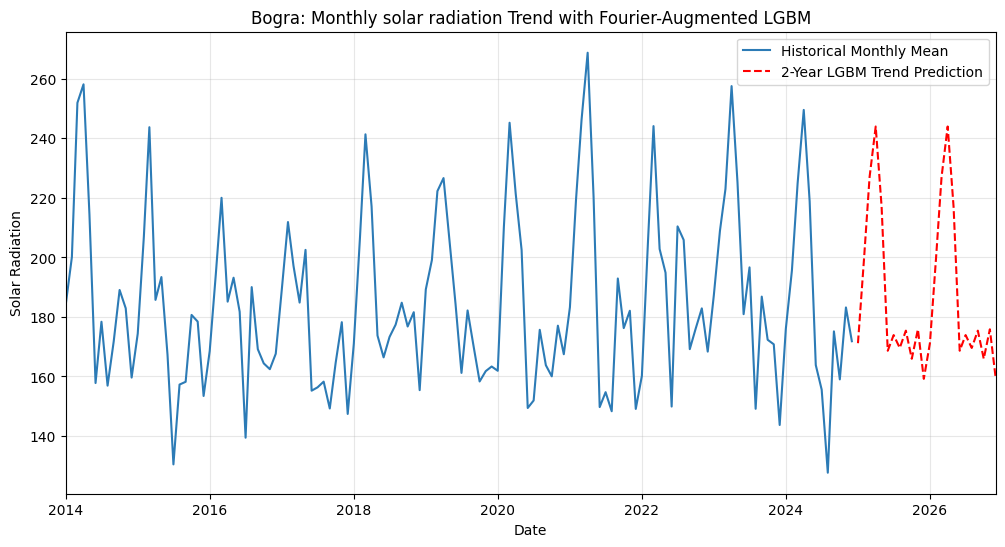

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor

# 1. Prepare Monthly Data
df = df_district.copy() # [cite: 101]
df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) # [cite: 116]
df_monthly_rad = df.set_index('date')['solar_radiation'].resample('MS').mean().reset_index()

# 2. Engineering Fourier Features for Seasonality
# This replaces the need for interpolation/splines
def add_fourier_features(df, period=12, n_terms=3): # Monthly period is 12
    for n in range(1, n_terms + 1):
        # Using month index (1-12) as the base for the cycle
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly_rad.copy())
df_features['year_val'] = df_features['date'].dt.year

# 3. Define Features and Target
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]
FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['solar_radiation']

# 4. Train Random Forest [cite: 145, 146]
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,         # Slowed down for stable trend learning
    max_depth=4,                # Restricted depth to prevent memorizing noise
    num_leaves=10,              # Low number of leaves is critical for small data
    min_child_samples=5,        # Minimum data points in a leaf (prevents tiny, specific branches)
    
    subsample=0.7,              # Stochastic bagging for robustness
    subsample_freq=1,
    colsample_bytree=0.7,       # Feature bagging
    
    reg_alpha=0.2,              # L1 regularization
    reg_lambda=0.2,             # L2 regularization
    
    importance_type='gain',     # More useful for understanding "Shape" than 'split'
    random_state=42,
    n_jobs=-1,
    verbosity=-1                # Suppress warnings about small dataset
)

lgb_model.fit(X_train, y_train)

# 5. Predict 2 Years Future (24 months)
last_date = df_features['date'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=24, freq='MS')
future_df = pd.DataFrame({'date': future_dates})
future_df['year_val'] = future_df['date'].dt.year
future_df = add_fourier_features(future_df)

predictions_solar = lgb_model.predict(future_df[FEATURES])

# 6. Visualization
plt.figure(figsize=(12, 6))
plt.plot(df_features['date'], y, label='Historical Monthly Mean', color='#2c7bb6') # [cite: 80]
plt.plot(future_dates, predictions_solar, label='2-Year LGBM Trend Prediction', linestyle='--', color='red')
plt.title('Bogra: Monthly solar radiation Trend with Fourier-Augmented LGBM')
plt.xlabel('Date')
plt.ylabel('Solar Radiation')
plt.legend()
plt.grid(True, alpha=0.3)
# Set the start date to Jan 1st, 2023
plt.xlim(pd.Timestamp('2014-01-01'), future_dates.max())
plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\p'
<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:21: SyntaxWarning: invalid escape sequence '\p'
<>:25: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Khalid\AppData\Local\Temp\ipykernel_21580\1853067801.py:21: SyntaxWarning: invalid escape sequence '\p'
  color='red', alpha=0.08, label='95% Prediction Interval ($\pm 1.96 \sigma$)')
C:\Users\Khalid\AppData\Local\Temp\ipykernel_21580\1853067801.py:25: SyntaxWarning: invalid escape sequence '\p'
  color='red', alpha=0.18, label=f'RMSE Uncertainty ($\pm${lgb_rmse_f:.2f})')


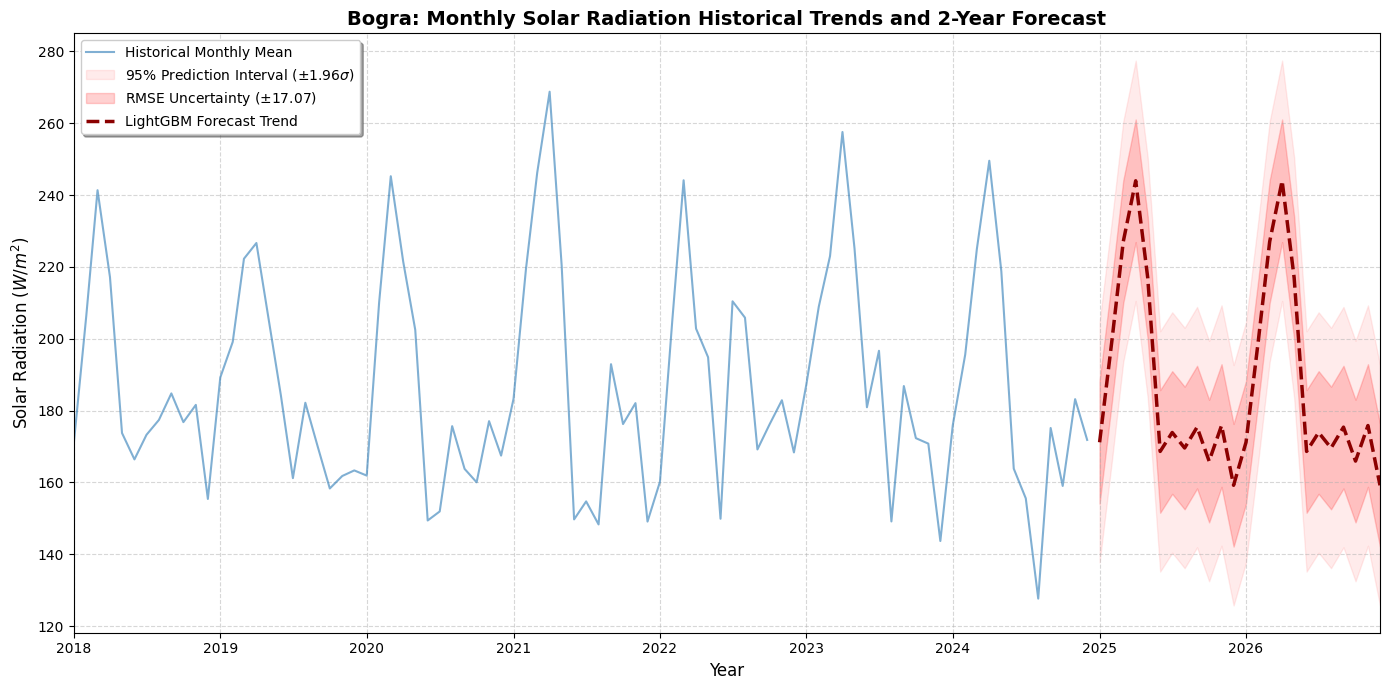

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

mean_preds = lgb_model.predict(future_df[FEATURES])
# 1. Define the Uncertainty Bounds (Based on your LightGBM RMSE)
best_model_rmse = 17.0697
upper_95 = mean_preds + (1.96 * best_model_rmse)
lower_95 = mean_preds - (1.96 * best_model_rmse)
upper_68 = mean_preds + best_model_rmse
lower_68 = mean_preds - best_model_rmse
# 2. Setup the Plot
plt.figure(figsize=(14, 7))

# 3. Plot Historical Data (The Context)
# Ensure df_features['date'] is in datetime format
plt.plot(df_features['date'], y, label='Historical Monthly Mean', 
         color='#2c7bb6', alpha=0.6, linewidth=1.5)

# 4. Plot the 95% Confidence Interval (The Outer Cloud)
plt.fill_between(future_dates, lower_95, upper_95, 
                 color='red', alpha=0.08, label='95% Prediction Interval ($\pm 1.96 \sigma$)')

# 5. Plot the 68% Confidence Interval (The RMSE Cloud)
plt.fill_between(future_dates, lower_68, upper_68, 
                 color='red', alpha=0.18, label=f'RMSE Uncertainty ($\pm${lgb_rmse_f:.2f})')

# 6. Plot the Future Prediction Mean (The Trend)
plt.plot(future_dates, mean_preds, label='LightGBM Forecast Trend', 
         linestyle='--', color='darkred', lw=2.5)

# 7. Journal Formatting & Aesthetics
plt.title('Bogra: Monthly Solar Radiation Historical Trends and 2-Year Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Solar Radiation ($W/m^2$)', fontsize=12)

# Set the x-axis to start slightly before the forecast for better perspective
# Adjust '2018-01-01' to whatever date makes your historical trend visible
plt.xlim(pd.Timestamp('2018-01-01'), future_dates.max()) 

plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

# Optional: Tight layout to prevent label clipping
plt.tight_layout()

plt.show()

In [ ]:
df_predictions_solar = pd.DataFrame({
    'date' : future_dates,
    'predicted_solar' : predictions_solar
})

df_predictions_solar

,date,predicted_solar
0,2025-01-01,171.184280
1,2025-02-01,199.776897
2,2025-03-01,227.045293
3,2025-04-01,243.980848
4,2025-05-01,216.967615
5,2025-06-01,168.640141
6,2025-07-01,173.907925
7,2025-08-01,169.592797
8,2025-09-01,175.397296
9,2025-10-01,165.949568


# Heat Index 

  Calculating heat index with 1980-2024 raw data

In [ ]:
import pandas as pd

df_district_2024 = pd.read_csv(f"../../../1980-2024-dataset/{district}_historical_weather_1980_2024.csv")

df = df_district_2024.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

df_monthly_hum = df.set_index('date')['humidity'].resample('MS').mean().reset_index()
df_monthly_hum = df_monthly_hum.interpolate(method='linear').dropna()

df_monthly_temp = df.set_index('date')['temperature(degree C)'].resample('MS').mean().reset_index()
df_monthly_temp = df_monthly_temp.interpolate(method='linear').dropna()

df_HI_2024_interpolated = pd.DataFrame()
df_HI_2024_interpolated['date'] = df_monthly_temp['date']
df_HI_2024_interpolated['temperature'] = df_monthly_temp['temperature(degree C)']
df_HI_2024_interpolated['humidity'] = df_monthly_hum['humidity']


# Heat Index Function
def calculate_heat_index(temperature_c, humidity):

    t_c = float(temperature_c)
    h = float(humidity)

    if 0.0 <= h <= 1.0:
        h = h * 100.0

    t_f = t_c * 9.0/5.0 + 32.0

    hi = 0.5 * (t_f + 61.0 + ((t_f - 68.0) * 1.2) + (h * 0.094))

    if hi >= 80.0:
        T = t_f
        R = h
        hi = (-42.379 + 2.04901523*T + 10.14333127*R
              - 0.22475541*T*R - 6.83783e-3*T**2
              - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
              + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)

    hi_c = (hi - 32.0) * 5.0/9.0
    return hi_c


# Calculate Heat Index
df_HI_2024_interpolated['heat_index_C'] = df_HI_2024_interpolated.apply(
    lambda r: calculate_heat_index(r['temperature'], r['humidity']),
    axis=1
)


df_HI_2024_interpolated


,date,temperature,humidity,heat_index_C
0,1980-01-01,18.145161,70.877419,17.865921
1,1980-02-01,20.786207,68.858621,20.718358
2,1980-03-01,25.848387,68.377419,26.274192
3,1980-04-01,29.960000,70.350000,35.024847
4,1980-05-01,28.058065,78.425806,31.999325
...,...,...,...,...
535,2024-08-01,28.435484,87.080645,34.563820
536,2024-09-01,29.586667,83.763333,37.414191
537,2024-10-01,27.548387,86.551613,31.863737
538,2024-11-01,24.276667,80.273333,24.855915


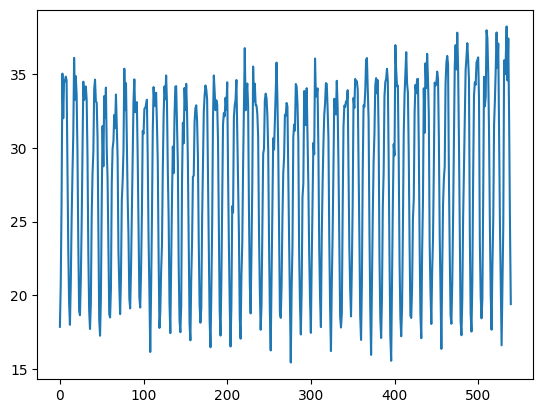

In [ ]:
import matplotlib.pyplot as plt

plt.plot(df_HI_2024_interpolated['heat_index_C'])

In [ ]:
import pandas as pd

df_district_2024 = pd.read_csv(f"../../../1980-2024-dataset/{district}_historical_weather_1980_2024.csv")

df = df_district_2024.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

df_monthly_hum = df.set_index('date')['humidity'].interpolate(method='linear').reset_index()
df_monthly_hum = df_monthly_hum.interpolate(method='linear').dropna()

df_monthly_temp = df.set_index('date')['temperature(degree C)'].interpolate(method='linear').reset_index()
df_monthly_temp = df_monthly_temp.interpolate(method='linear').dropna()

df_HI_2024 = pd.DataFrame()
df_HI_2024['date'] = df_monthly_temp['date']
df_HI_2024['temperature'] = df_monthly_temp['temperature(degree C)']
df_HI_2024['humidity'] = df_monthly_hum['humidity']


# Heat Index Function
def calculate_heat_index(temperature_c, humidity):

    t_c = float(temperature_c)
    h = float(humidity)

    if 0.0 <= h <= 1.0:
        h = h * 100.0

    t_f = t_c * 9.0/5.0 + 32.0

    hi = 0.5 * (t_f + 61.0 + ((t_f - 68.0) * 1.2) + (h * 0.094))

    if hi >= 80.0:
        T = t_f
        R = h
        hi = (-42.379 + 2.04901523*T + 10.14333127*R
              - 0.22475541*T*R - 6.83783e-3*T**2
              - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
              + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)

    hi_c = (hi - 32.0) * 5.0/9.0
    return hi_c


# Calculate Heat Index
df_HI_2024['heat_index_C'] = df_HI_2024.apply(
    lambda r: calculate_heat_index(r['temperature'], r['humidity']),
    axis=1
)


df_HI_2024


,date,temperature,humidity,heat_index_C
0,1980-01-01,18.2,74.2,18.013000
1,1980-01-02,16.9,82.9,16.810167
2,1980-01-03,18.2,81.2,18.195778
3,1980-01-04,17.4,81.2,17.315778
4,1980-01-05,18.6,70.3,18.351167
...,...,...,...,...
16432,2024-12-27,19.2,80.7,19.282722
16433,2024-12-28,19.7,79.8,19.809222
16434,2024-12-29,19.4,80.0,19.484444
16435,2024-12-30,19.8,80.3,19.932278


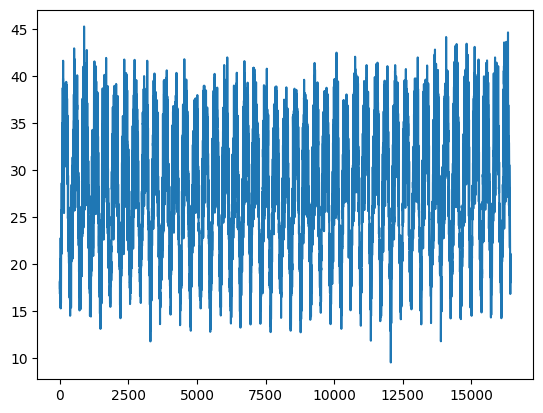

In [ ]:
import matplotlib.pyplot as plt

plt.plot(df_HI_2024['heat_index_C'])
# plt.xlim(pd.Timestamp('2014-01-01'))

Calculating heat index with 2025 raw data

In [ ]:
# import pandas as pd

# df_district_2025 = pd.read_csv("../2025-dataset/Bogra_historical_weather_2025.csv")

# df = df_district_2025.copy()
# df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

# df_monthly_hum = df.set_index('date')['humidity'].resample('MS').mean().reset_index()
# df_monthly_hum = df_monthly_hum.interpolate(method='linear').dropna()

# df_monthly_temp = df.set_index('date')['temperature(degree C)'].resample('MS').mean().reset_index()
# df_monthly_temp = df_monthly_temp.interpolate(method='linear').dropna()

# df_HI_2025 = pd.DataFrame()
# df_HI_2025['date'] = df_monthly_temp['date']
# df_HI_2025['temperature'] = df_monthly_temp['temperature(degree C)']
# df_HI_2025['humidity'] = df_monthly_hum['humidity']


# # Heat Index Function
# def calculate_heat_index(temperature_c, humidity):

#     t_c = float(temperature_c)
#     h = float(humidity)

#     if 0.0 <= h <= 1.0:
#         h = h * 100.0

#     t_f = t_c * 9.0/5.0 + 32.0

#     hi = 0.5 * (t_f + 61.0 + ((t_f - 68.0) * 1.2) + (h * 0.094))

#     if hi >= 80.0:
#         T = t_f
#         R = h
#         hi = (-42.379 + 2.04901523*T + 10.14333127*R
#               - 0.22475541*T*R - 6.83783e-3*T**2
#               - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
#               + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)

#     hi_c = (hi - 32.0) * 5.0/9.0
#     return hi_c


# # Calculate Heat Index
# df_HI_2025['heat_index_C'] = df_HI_2025.apply(
#     lambda r: calculate_heat_index(r['temperature'], r['humidity']),
#     axis=1
# )


# print(df_HI_2025)


In [ ]:
import pandas as pd

df_district_2025 = pd.read_csv(f"../../../2025-dataset/{district}_historical_weather_2025.csv")

df = df_district_2025.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

# Removed .resample('MS').mean() to keep daily granularity
df_monthly_hum = df.set_index('date')['humidity'].interpolate(method='linear').reset_index()
df_monthly_hum = df_monthly_hum.dropna()

# Removed .resample('MS').mean() to keep daily granularity
df_monthly_temp = df.set_index('date')['temperature(degree C)'].interpolate(method='linear').reset_index()
df_monthly_temp = df_monthly_temp.dropna()

df_HI_2025 = pd.DataFrame()
df_HI_2025['date'] = df_monthly_temp['date']
df_HI_2025['temperature'] = df_monthly_temp['temperature(degree C)']
df_HI_2025['humidity'] = df_monthly_hum['humidity']


# Heat Index Function
def calculate_heat_index(temperature_c, humidity):

    t_c = float(temperature_c)
    h = float(humidity)

    if 0.0 <= h <= 1.0:
        h = h * 100.0

    t_f = t_c * 9.0/5.0 + 32.0

    hi = 0.5 * (t_f + 61.0 + ((t_f - 68.0) * 1.2) + (h * 0.094))

    if hi >= 80.0:
        T = t_f
        R = h
        hi = (-42.379 + 2.04901523*T + 10.14333127*R
              - 0.22475541*T*R - 6.83783e-3*T**2
              - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
              + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)

    hi_c = (hi - 32.0) * 5.0/9.0
    return hi_c


# Calculate Heat Index
df_HI_2025['heat_index_C'] = df_HI_2025.apply(
    lambda r: calculate_heat_index(r['temperature'], r['humidity']),
    axis=1
)


print(df_HI_2025)

          date  temperature  humidity  heat_index_C
0   2025-01-01         17.0      95.0     17.236111
1   2025-01-02         16.9      92.5     17.060833
2   2025-01-03         16.6      93.8     16.764778
3   2025-01-04         19.0      87.3     19.235056
4   2025-01-05         20.7      81.8     20.961444
..         ...          ...       ...           ...
319 2025-11-16         23.3      76.5     23.683056
320 2025-11-17         23.3      78.2     23.727444
321 2025-11-18         23.4      74.6     23.743444
322 2025-11-19         23.6      72.1     23.898167
323 2025-11-20         23.2      68.7     23.369389

[324 rows x 4 columns]


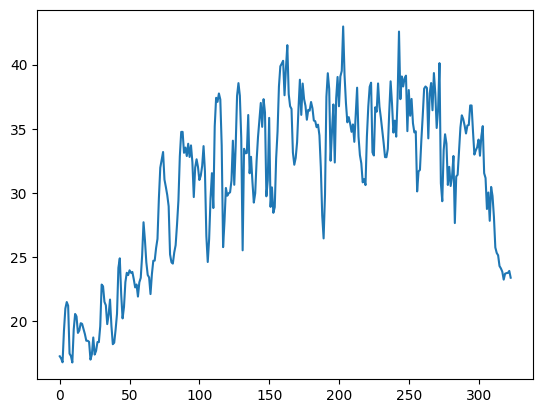

In [ ]:
import matplotlib.pyplot as plt
plt.plot(df_HI_2025['heat_index_C'])

 Calculating heat index using predicted temperature and humidity

In [ ]:
df_HI = pd.DataFrame()

# Add predicted temperature and humidity
df_HI['predicted_temp'] = df_predictions_temp['predicted_temp'].values
df_HI['predicted_humidity'] = df_predictions_humidity['predicted_humidity'].values


# Column names
temp_col = 'predicted_temp'
hum_col = 'predicted_humidity'


# Heat Index calculation function
def calculate_heat_index(temperature_c, humidity):

    t_c = float(temperature_c)
    h = float(humidity)

    # If humidity is fraction convert to %
    if 0.0 <= h <= 1.0:
        h = h * 100.0

    # Convert Celsius → Fahrenheit
    t_f = t_c * 9.0/5.0 + 32.0

    # Simple heat index approximation
    hi = 0.5 * (t_f + 61.0 + ((t_f - 68.0) * 1.2) + (h * 0.094))

    # Full NOAA/NWS formula
    if hi >= 80.0:
        T = t_f
        R = h

        hi = (-42.379 + 2.04901523*T + 10.14333127*R
              - 0.22475541*T*R - 6.83783e-3*T**2
              - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
              + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)

    # Convert Fahrenheit → Celsius
    hi_c = (hi - 32.0) * 5.0/9.0

    return hi_c


# Calculate heat index for predictions
df_HI['predicted_heat_index_C'] = df_HI.apply(
    lambda r: calculate_heat_index(r[temp_col], r[hum_col]),
    axis=1
)

# Inspect results

print(df_HI)

    predicted_temp  predicted_humidity  predicted_heat_index_C
0        17.755384           84.851787               17.802053
1        20.626574           76.474647               20.741625
2        25.995973           73.247388               26.563697
3        28.783582           74.097493               32.996616
4        28.698726           79.081904               33.734919
5        28.569975           85.485347               34.652784
6        29.121091           84.148922               36.043985
7        29.497105           84.843049               37.415273
8        29.056182           86.101784               36.307849
9        27.739745           85.434279               32.236245
10       23.563223           81.281691               24.097456
11       19.319868           83.445741               19.486271
12       17.755384           84.851787               17.802053
13       20.626574           76.474647               20.741625
14       25.995973           73.247388               26

## Plotting real vs predicted heat index

![image.png](attachment:image.png)

error propagation cloud 

In [ ]:
# sigma heat index calculation
import numpy as np
temp_rmse = 0.8683 
humidity_rmse = 1.9038
hi_rmse = np.sqrt( (1.1 * temp_rmse)**2 + (0.1 * humidity_rmse)**2 )

C:\Users\Khalid\AppData\Local\Temp\ipykernel_21580\2557569152.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_HI_pred_plot['upper_95'] = df_HI_pred_plot['predicted_heat_index_C'] + (1.96 * hi_rmse) # Statistics tells us that in a perfect "Bell Curve" (Normal Distribution), 95% of all values fall within 1.96 standard deviations of the mean.
C:\Users\Khalid\AppData\Local\Temp\ipykernel_21580\2557569152.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_HI_pred_plot['lower_95'] = df_HI_pred_plot['

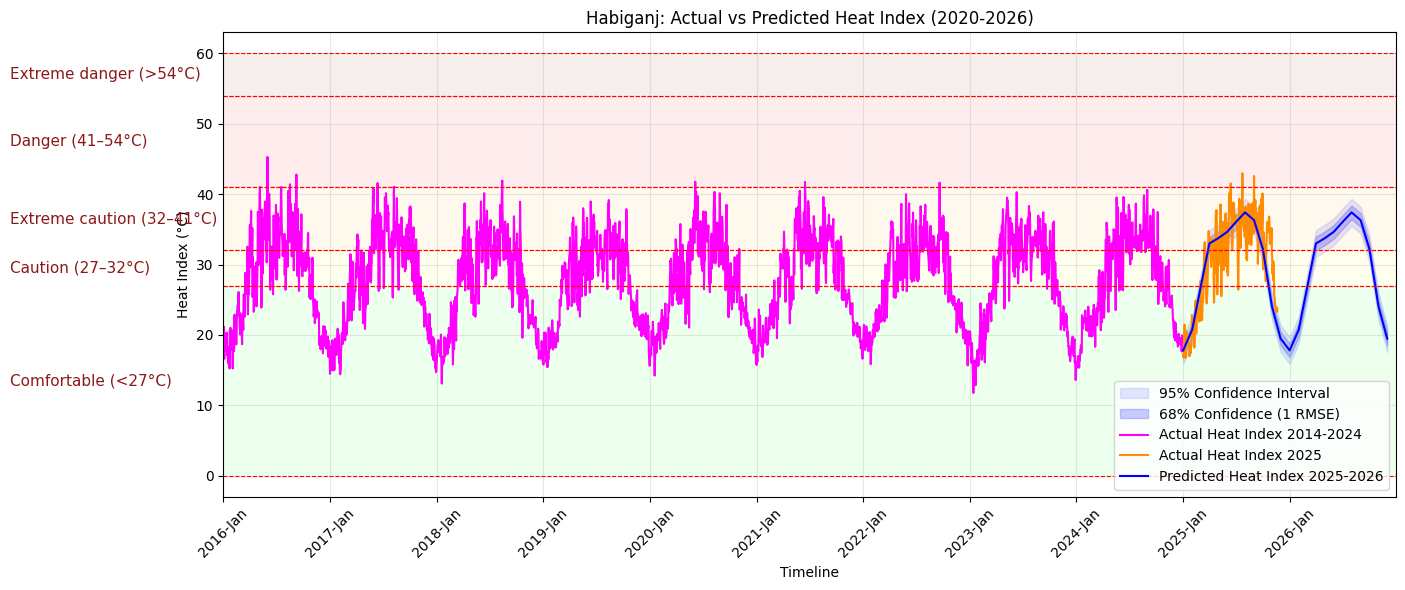

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(14,6))

# --- Ensure datetime index for monthly data ---

# df_HI_2024_interpolated = df_HI_2024_interpolated.copy()
# df_HI_2024_interpolated['date'] = pd.date_range(start='2014-01-01', periods=len(df_HI_2024_interpolated), freq='MS')
# df_HI_2024_interpolated = df_HI_2024_interpolated.set_index('date')

df_HI_2024 = df_HI_2024.copy()
df_HI_2024['date'] = pd.date_range(start='2014-01-01', periods=len(df_HI_2024))
df_HI_2024 = df_HI_2024.set_index('date')

df_HI_2025 = df_HI_2025.copy()
df_HI_2025['date'] = pd.date_range(start='2025-01-01', periods=len(df_HI_2025))
df_HI_2025 = df_HI_2025.set_index('date')

df_HI = df_HI.copy()
df_HI['date'] = pd.date_range(start='2025-01-01', periods=len(df_HI), freq='MS')
df_HI = df_HI.set_index('date')

# --- Filter ranges ---
# df_HI_2024_interpolated_plot = df_HI_2024_interpolated.loc['2014-01-01':'2024-12-31']
df_HI_2024_plot = df_HI_2024.loc['2014-01-01':'2024-12-31']
df_HI_2025_plot = df_HI_2025.loc['2025-01-01':'2025-12-31']
df_HI_pred_plot = df_HI.loc['2025-01-01':'2026-12-31']


# --- Define RMSE for Heat Index ---
# Replace this with your actual Heat Index model RMSE
hi_rmse #########################################################################  

# Calculate bounds for the prediction DataFrame
df_HI_pred_plot['upper_95'] = df_HI_pred_plot['predicted_heat_index_C'] + (1.96 * hi_rmse) # Statistics tells us that in a perfect "Bell Curve" (Normal Distribution), 95% of all values fall within 1.96 standard deviations of the mean.
df_HI_pred_plot['lower_95'] = df_HI_pred_plot['predicted_heat_index_C'] - (1.96 * hi_rmse)
df_HI_pred_plot['upper_68'] = df_HI_pred_plot['predicted_heat_index_C'] + hi_rmse
df_HI_pred_plot['lower_68'] = df_HI_pred_plot['predicted_heat_index_C'] - hi_rmse

# --- Plot the Confidence Cloud ---

# 95% Confidence Interval (Lighter Blue)
plt.fill_between(df_HI_pred_plot.index, 
                 df_HI_pred_plot['lower_95'], 
                 df_HI_pred_plot['upper_95'], 
                 color='blue', alpha=0.1, label='95% Confidence Interval')

# 68% Confidence Interval (Slightly Darker Blue)
plt.fill_between(df_HI_pred_plot.index, 
                 df_HI_pred_plot['lower_68'], 
                 df_HI_pred_plot['upper_68'], 
                 color='blue', alpha=0.2, label='68% Confidence (1 RMSE)')




# --- Plot actual vs predicted ---

plt.plot(df_HI_2024_plot.index, df_HI_2024_plot['heat_index_C'], 
         label='Actual Heat Index 2014-2024', color='magenta')

plt.plot(df_HI_2025_plot.index, df_HI_2025_plot['heat_index_C'], 
         label='Actual Heat Index 2025', color='darkorange')

plt.plot(df_HI_pred_plot.index, df_HI_pred_plot['predicted_heat_index_C'], 
         label='Predicted Heat Index 2025-2026', color='blue')
# plt.plot(df_HI_2024_interpolated_plot.index, df_HI_2024_interpolated_plot['heat_index_C'],
#          label='Actual monthly interpolated Heat Index 2014-2024', color='black')

# --- Labels and title ---
plt.xlabel('Timeline')
plt.ylabel('Heat Index (°C)')
plt.title(f'{district}: Actual vs Predicted Heat Index (2020-2026)')

# --- Heat index bands ---
bands = [
    (0, 27, "Comfortable (<27°C)", (0, 1, 0, 0.07)),        # Green
    (27, 32, "Caution (27–32°C)", (1, 1, 0, 0.07)),          # Yellow
    (32, 41, "Extreme caution (32–41°C)", (1, 0.65, 0, 0.07)), # Orange
    (41, 54, "Danger (41–54°C)", (1, 0, 0, 0.07)),           # Red
    (54, 60, "Extreme danger (>54°C)", (0.5, 0, 0, 0.07))    # Dark Red
]

ax = plt.gca()
for low, high, label, color in bands:
    ax.axhspan(low, high, facecolor=color, edgecolor=None)
    plt.axhline(y=low, color='red', linestyle='--', linewidth=0.8)
    plt.axhline(y=high, color='red', linestyle='--', linewidth=0.8)
    plt.text(
        x=df_HI_2024_plot.index.min(),
        y=(low + high)/2,
        s=label,
        fontsize=11,
        color="maroon",
        va="center",
        ha="left",
        alpha=0.9
    )

# --- X-axis formatting ---
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.xlim(pd.Timestamp('2016-01-01'), pd.Timestamp('2026-12-31'))

plt.legend()
plt.tight_layout()
plt.show()

# Wet Bulb

Calculating wet bulb with 1980-2024 raw data

In [ ]:
import pandas as pd
import numpy as np

df_district_2024 = pd.read_csv(f"../../../1980-2024-dataset/{district}_historical_weather_1980_2024.csv")

df = df_district_2024.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

df_monthly_hum = df.set_index('date')['humidity'].interpolate(method='linear').reset_index()
df_monthly_hum = df_monthly_hum.interpolate(method='linear').dropna()

df_monthly_temp = df.set_index('date')['temperature(degree C)'].interpolate(method='linear').reset_index()
df_monthly_temp = df_monthly_temp.interpolate(method='linear').dropna()

df_WB_2024 = pd.DataFrame()
df_WB_2024['date'] = df_monthly_temp['date']
df_WB_2024['temperature'] = df_monthly_temp['temperature(degree C)']
df_WB_2024['humidity'] = df_monthly_hum['humidity']


# Wet Bulb Function (Stull's Equation)
def calculate_wet_bulb(temperature_c, humidity):

    T = float(temperature_c)
    RH = float(humidity)

    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0

    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )

    return Tw


# Calculate Wet Bulb Temperature
df_WB_2024['wet_bulb_C'] = df_WB_2024.apply(
    lambda r: calculate_wet_bulb(r['temperature'], r['humidity']),
    axis=1
)

df_WB_2024

,date,temperature,humidity,wet_bulb_C
0,1980-01-01,18.2,74.2,15.107281
1,1980-01-02,16.9,82.9,14.889845
2,1980-01-03,18.2,81.2,15.944595
3,1980-01-04,17.4,81.2,15.174019
4,1980-01-05,18.6,70.3,15.012348
...,...,...,...,...
16432,2024-12-27,19.2,80.7,16.846745
16433,2024-12-28,19.7,79.8,17.216551
16434,2024-12-29,19.4,80.0,16.953240
16435,2024-12-30,19.8,80.3,17.374391


 Calculating wet bulb with 2025 raw data

In [ ]:
import pandas as pd
import numpy as np

df_district_2025 = pd.read_csv(f"../../../2025-dataset/{district}_historical_weather_2025.csv")

df = df_district_2025.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

df_monthly_hum = df.set_index('date')['humidity'].interpolate(method='linear').reset_index()
df_monthly_hum = df_monthly_hum.dropna()

df_monthly_temp = df.set_index('date')['temperature(degree C)'].interpolate(method='linear').reset_index()
df_monthly_temp = df_monthly_temp.dropna()

df_WB_2025 = pd.DataFrame()
df_WB_2025['date'] = df_monthly_temp['date']
df_WB_2025['temperature'] = df_monthly_temp['temperature(degree C)']
df_WB_2025['humidity'] = df_monthly_hum['humidity']


# Wet Bulb Function (Stull's Equation)
def calculate_wet_bulb(temperature_c, humidity):

    T = float(temperature_c)
    RH = float(humidity)

    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0

    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )

    return Tw


# Calculate Wet Bulb Temperature
df_WB_2025['wet_bulb_C'] = df_WB_2025.apply(
    lambda r: calculate_wet_bulb(r['temperature'], r['humidity']),
    axis=1
)

print(df_WB_2025)

          date  temperature  humidity  wet_bulb_C
0   2025-01-01         17.0      95.0   16.400461
1   2025-01-02         16.9      92.5   16.008220
2   2025-01-03         16.6      93.8   15.862181
3   2025-01-04         19.0      87.3   17.456560
4   2025-01-05         20.7      81.8   18.428249
..         ...          ...       ...         ...
319 2025-11-16         23.3      76.5   20.230321
320 2025-11-17         23.3      78.2   20.457544
321 2025-11-18         23.4      74.6   20.070032
322 2025-11-19         23.6      72.1   19.920073
323 2025-11-20         23.2      68.7   19.084665

[324 rows x 4 columns]


Calculating wet bulb using predicted temperature and humidity

In [ ]:
df_WB = pd.DataFrame()

# Add predicted temperature and humidity
df_WB['predicted_temp'] = df_predictions_temp['predicted_temp'].values
df_WB['predicted_humidity'] = df_predictions_humidity['predicted_humidity'].values


# Column names
temp_col = 'predicted_temp'
hum_col = 'predicted_humidity'


def calculate_wet_bulb(temperature_c, humidity):

    T = float(temperature_c)
    RH = float(humidity)

    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0

    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )

    return Tw


# Calculate wet bulb temperature for predictions
df_WB['predicted_wet_bulb_C'] = df_WB.apply(
    lambda r: calculate_wet_bulb(r[temp_col], r[hum_col]),
    axis=1
)

# Inspect results

print(df_WB)

    predicted_temp  predicted_humidity  predicted_wet_bulb_C
0        17.755384           84.851787             15.948599
1        20.626574           76.474647             17.685966
2        25.995973           73.247388             22.331094
3        28.783582           74.097493             25.082859
4        28.698726           79.081904             25.744898
5        28.569975           85.485347             26.558313
6        29.121091           84.148922             26.898976
7        29.497105           84.843049             27.366623
8        29.056182           86.101784             27.122132
9        27.739745           85.434279             25.742266
10       23.563223           81.281691             21.121435
11       19.319868           83.445741             17.298131
12       17.755384           84.851787             15.948599
13       20.626574           76.474647             17.685966
14       25.995973           73.247388             22.331094
15       28.783582      

https://journals.ametsoc.org/view/journals/apme/50/11/jamc-d-11-0143.1.xml

![image.png](attachment:image.png)

![image-2.png](attachment:image-2.png)

In [ ]:
import numpy as np

wb_rmse = np.sqrt( (0.6 * 0.8975)**2 + (0.2 * 2.689614)**2 )

## Plotting real vs predicted wet bulb

C:\Users\Khalid\AppData\Local\Temp\ipykernel_21580\2186352038.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_WB_pred_plot['upper_95'] = df_WB_pred_plot['predicted_wet_bulb_C'] + (1.96 * wb_rmse) # Statistics tells us that in a perfect "Bell Curve" (Normal Distribution), 95% of all values fall within 1.96 standard deviations of the mean.
C:\Users\Khalid\AppData\Local\Temp\ipykernel_21580\2186352038.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_WB_pred_plot['lower_95'] = df_WB_pred_plot['pr

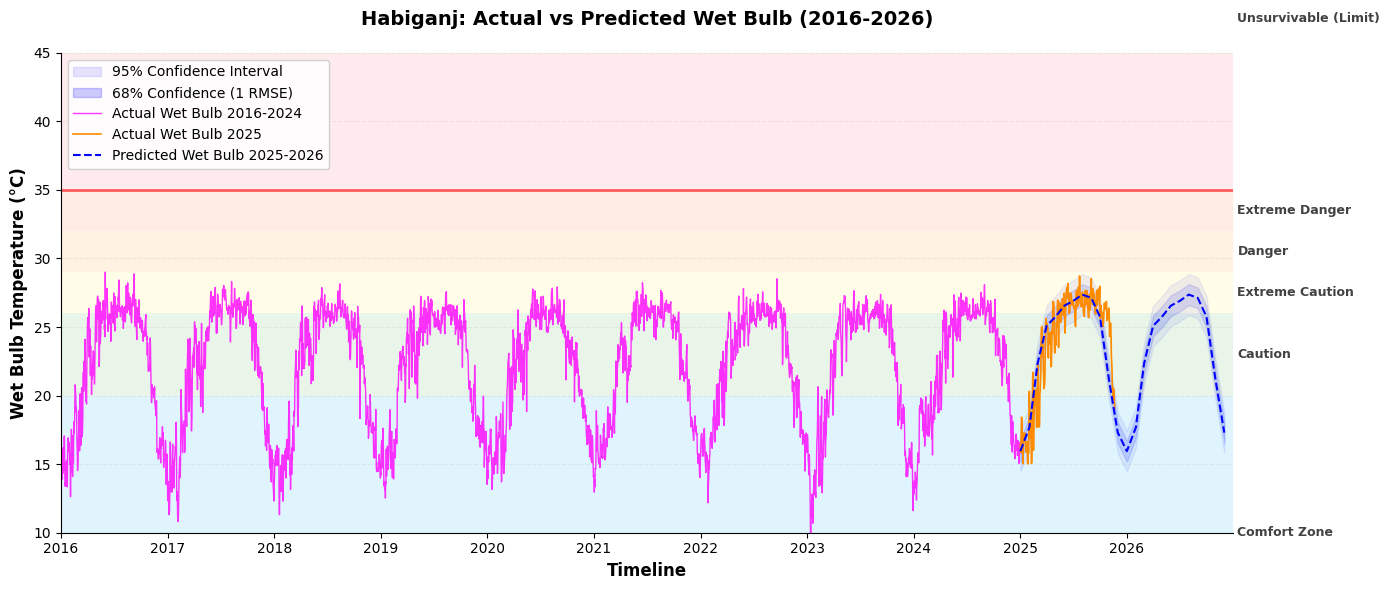

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(14,6))

# --- Ensure datetime index for monthly data ---
df_WB_2024 = df_WB_2024.copy()
df_WB_2024['date'] = pd.date_range(start='2014-01-01', periods=len(df_WB_2024)) ########################
df_WB_2024 = df_WB_2024.set_index('date')

df_WB_2025 = df_WB_2025.copy()
df_WB_2025['date'] = pd.date_range(start='2025-01-01', periods=len(df_WB_2025))
df_WB_2025 = df_WB_2025.set_index('date')

df_WB = df_WB.copy()
df_WB['date'] = pd.date_range(start='2025-01-01', periods=len(df_WB), freq='MS')
df_WB = df_WB.set_index('date')

# --- Filter ranges ---
df_WB_2024_plot = df_WB_2024.loc['2014-01-01':'2024-12-31']
df_WB_2025_plot = df_WB_2025.loc['2025-01-01':'2025-12-31']
df_WB_pred_plot = df_WB.loc['2025-01-01':'2026-12-31']


# --- Define RMSE for wet bulb ---
# Replace this with your actual Wet Bulb model RMSE
wb_rmse #########################################################################  

# Calculate bounds for the prediction DataFrame
df_WB_pred_plot['upper_95'] = df_WB_pred_plot['predicted_wet_bulb_C'] + (1.96 * wb_rmse) # Statistics tells us that in a perfect "Bell Curve" (Normal Distribution), 95% of all values fall within 1.96 standard deviations of the mean.
df_WB_pred_plot['lower_95'] = df_WB_pred_plot['predicted_wet_bulb_C'] - (1.96 * wb_rmse)
df_WB_pred_plot['upper_68'] = df_WB_pred_plot['predicted_wet_bulb_C'] + wb_rmse
df_WB_pred_plot['lower_68'] = df_WB_pred_plot['predicted_wet_bulb_C'] - wb_rmse

# --- Plot the Confidence Cloud ---

# 95% Confidence Interval (Lighter Blue)
plt.fill_between(df_WB_pred_plot.index, 
                 df_WB_pred_plot['lower_95'], 
                 df_WB_pred_plot['upper_95'], 
                 color='blue', alpha=0.1, label='95% Confidence Interval')

# 68% Confidence Interval (Slightly Darker Blue)
plt.fill_between(df_WB_pred_plot.index, 
                 df_WB_pred_plot['lower_68'], 
                 df_WB_pred_plot['upper_68'], 
                 color='blue', alpha=0.2, label='68% Confidence (1 RMSE)')

# --- Plot actual vs predicted ---
plt.plot(df_WB_2024_plot.index, df_WB_2024_plot['wet_bulb_C'],
         label='Actual Wet Bulb 2016-2024', color='magenta', linewidth=1, alpha=0.8)

plt.plot(df_WB_2025_plot.index, df_WB_2025_plot['wet_bulb_C'],
         label='Actual Wet Bulb 2025', color='darkorange', linewidth=1.2)

plt.plot(df_WB_pred_plot.index, df_WB_pred_plot['predicted_wet_bulb_C'],
         label='Predicted Wet Bulb 2025-2026', color='blue', linestyle='--', linewidth=1.5)

# --- Labels and title ---
plt.xlabel('Timeline', fontsize=12, fontweight='bold')
plt.ylabel('Wet Bulb Temperature (°C)', fontsize=12, fontweight='bold')
plt.title(f'{district}: Actual vs Predicted Wet Bulb (2016-2026)', 
          fontsize=14, pad=20, fontweight='bold')

# --- Comfort & Danger Boundary Conditions ---
ax = plt.gca()

# Defining the zones: (Bottom_Temp, Top_Temp, Color, Label)
zones = [
    (0, 20, '#b3e5fc', 'Comfort Zone'),           # Light Blue
    (20, 26, '#c8e6c9', 'Caution'),                # Light Green
    (26, 29, '#fff9c4', 'Extreme Caution'),        # Light Yellow
    (29, 32, '#ffe0b2', 'Danger'),                 # Light Orange
    (32, 35, '#ffccbc', 'Extreme Danger'),         # Light Red/Coral
    (35, 60, '#ffcdd2', 'Unsurvivable (Limit)')    # Deep Red
]

for bottom, top, color, label in zones:
    ax.axhspan(bottom, top, facecolor=color, alpha=0.4, edgecolor=None)
    # Adding subtle text labels on the right edge for a clean journal look
    plt.text(pd.Timestamp('2027-01-15'), (bottom + top) / 2, label, 
             fontsize=9, color='#424242', va='center', fontweight='bold')

# Highlight the critical 35°C threshold
plt.axhline(y=35, color='red', linestyle='-', linewidth=2, alpha=0.6)

# --- X-axis formatting ---
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=0) # Flat labels look cleaner in journals if space permits

plt.grid(axis='y', linestyle='--', alpha=0.2)
plt.xlim(pd.Timestamp('2016-01-01'), pd.Timestamp('2026-12-31'))
plt.ylim(10, 45) # Focused range for Wet Bulb visibility

# Clean up legend and spine
plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Wet Bulb Globe Temperature 

Calculating wet bulb globe with 1980-2024 raw data

In [ ]:
import pandas as pd
import numpy as np

df_district_2024 = pd.read_csv(f"../../../1980-2024-dataset/{district}_historical_weather_1980_2024.csv")

df = df_district_2024.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

df_monthly_hum = df.set_index('date')['humidity'].interpolate(method='linear').reset_index()
df_monthly_hum = df_monthly_hum.interpolate(method='linear').dropna()

df_monthly_temp = df.set_index('date')['temperature(degree C)'].interpolate(method='linear').reset_index()
df_monthly_temp = df_monthly_temp.interpolate(method='linear').dropna()

df_monthly_solar = df.set_index('date')['solar_radiation'].interpolate(method='linear').reset_index()
df_monthly_solar = df_monthly_solar.interpolate(method='linear').dropna()

df_WB_2024 = pd.DataFrame()
df_WB_2024['date'] = df_monthly_temp['date']
df_WB_2024['temperature'] = df_monthly_temp['temperature(degree C)']
df_WB_2024['humidity'] = df_monthly_hum['humidity']
df_WB_2024['solar_radiation'] = df_monthly_solar['solar_radiation']


# Wet Bulb Function (Stull's Equation)
def calculate_wet_bulb(temperature_c, humidity):

    T = float(temperature_c)
    RH = float(humidity)

    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0

    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )

    return Tw


# Calculate Wet Bulb Temperature
df_WB_2024['wet_bulb_C'] = df_WB_2024.apply(
    lambda r: calculate_wet_bulb(r['temperature'], r['humidity']),
    axis=1
)

df_WB_2024['WBGT'] = (
    0.7 * df_WB_2024['wet_bulb_C']
    + 0.2 * (df_WB_2024['temperature'] + 0.0003 * df_WB_2024['solar_radiation'])
    + 0.1 * df_WB_2024['temperature']
)


df_WBG_2024 = df_WB_2024[[
    'date',
    'temperature',
    'humidity',
    'solar_radiation',
    'wet_bulb_C',
    'WBGT'
]]

df_WBG_2024

,date,temperature,humidity,solar_radiation,wet_bulb_C,WBGT
0,1980-01-01,18.2,74.2,NaN,15.107281,NaN
1,1980-01-02,16.9,82.9,NaN,14.889845,NaN
2,1980-01-03,18.2,81.2,NaN,15.944595,NaN
3,1980-01-04,17.4,81.2,NaN,15.174019,NaN
4,1980-01-05,18.6,70.3,NaN,15.012348,NaN
...,...,...,...,...,...,...
16432,2024-12-27,19.2,80.7,181.9,16.846745,17.563636
16433,2024-12-28,19.7,79.8,180.4,17.216551,17.972410
16434,2024-12-29,19.4,80.0,174.6,16.953240,17.697744
16435,2024-12-30,19.8,80.3,178.9,17.374391,18.112808


Calculating wet bulb globe with 2025 raw data

In [ ]:
import pandas as pd
import numpy as np


df_2025 = pd.read_csv(f"../../../2025-dataset/{district}_historical_weather_2025.csv")

df_2025['date'] = pd.to_datetime(df_2025[['year', 'month', 'day']])


df_2025 = df_2025.set_index('date')

df_monthly_2025 = df_2025.resample('D')[[ ############### 
    'temperature(degree C)',
    'humidity',
    'solar_radiation'
]].mean()


full_range = pd.date_range(
    start='2025-01-01',
    end='2025-11-01',
    freq='D'
)

df_monthly_2025 = df_monthly_2025.reindex(full_range)


df_monthly_2025 = df_monthly_2025.interpolate(method='linear')


df_monthly_2025 = df_monthly_2025.reset_index()
df_monthly_2025.rename(columns={
    'index': 'date',
    'temperature(degree C)': 'temperature_C'
}, inplace=True)

def calculate_wet_bulb(T, RH):

    RH = np.where(RH <= 1, RH*100, RH)

    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )

    return Tw

df_monthly_2025['wet_bulb_C'] = calculate_wet_bulb(
    df_monthly_2025['temperature_C'],
    df_monthly_2025['humidity']
)


df_monthly_2025['WBGT'] = (
    0.7 * df_monthly_2025['wet_bulb_C']
    + 0.2 * (df_monthly_2025['temperature_C'] + 0.0003 * df_monthly_2025['solar_radiation'])
    + 0.1 * df_monthly_2025['temperature_C']
)


df_WBG_2025 = df_monthly_2025[[
    'date',
    'temperature_C',
    'humidity',
    'solar_radiation',
    'wet_bulb_C',
    'WBGT'
]]

df_WBG_2025

,date,temperature_C,humidity,solar_radiation,wet_bulb_C,WBGT
0,2025-01-01,17.0,95.0,166.5,16.400461,16.590312
1,2025-01-02,16.9,92.5,161.5,16.008220,16.285444
2,2025-01-03,16.6,93.8,171.7,15.862181,16.093829
3,2025-01-04,19.0,87.3,172.6,17.456560,17.929948
4,2025-01-05,20.7,81.8,177.4,18.428249,19.120418
...,...,...,...,...,...,...
300,2025-10-28,28.8,79.8,199.4,25.948101,26.815635
301,2025-10-29,28.2,81.7,179.8,25.649488,26.425430
302,2025-10-30,28.8,81.1,166.9,26.139890,26.947937
303,2025-10-31,29.1,80.8,168.8,26.384334,27.209162


In [ ]:
df_predictions_solar

,date,predicted_solar
0,2025-01-01,171.184280
1,2025-02-01,199.776897
2,2025-03-01,227.045293
3,2025-04-01,243.980848
4,2025-05-01,216.967615
5,2025-06-01,168.640141
6,2025-07-01,173.907925
7,2025-08-01,169.592797
8,2025-09-01,175.397296
9,2025-10-01,165.949568


## Calculating wet bulb globe with predicted values for next 2 years 

In [ ]:
import pandas as pd
import numpy as np

# Create dataframe
df_WBG = pd.DataFrame()

# Add date column (recommended for time series)
df_WBG['date'] = df_predictions_solar['date']

# Add predicted variables
df_WBG['predicted_temp'] = df_predictions_temp['predicted_temp'].values
df_WBG['predicted_humidity'] = df_predictions_humidity['predicted_humidity'].values
df_WBG['predicted_solar'] = df_predictions_solar['predicted_solar'].values


# Wet Bulb Function
def calculate_wet_bulb(temperature_c, humidity):

    T = float(temperature_c)
    RH = float(humidity)

    # Convert RH if given as fraction
    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0

    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )

    return Tw


# Calculate Wet Bulb Temperature
df_WBG['predicted_wet_bulb_C'] = df_WBG.apply(
    lambda r: calculate_wet_bulb(r['predicted_temp'], r['predicted_humidity']),
    axis=1
)


# Calculate WBGT
# WBGT ≈ 0.7 × Tw + 0.2 × (T + 0.025 × SR) + 0.1 × T

df_WBG['predicted_WBGT'] = (
    0.7 * df_WBG['predicted_wet_bulb_C']
    + 0.2 * (df_WBG['predicted_temp'] + 0.025 * df_WBG['predicted_solar'])
    + 0.1 * df_WBG['predicted_temp']
)

# reference for changing 0.0003 to 0.025 https://www.iaeng.org/publication/WCECS2011/WCECS2011_pp591-599.pdf

df_WBG

,date,predicted_temp,predicted_humidity,predicted_solar,predicted_wet_bulb_C,predicted_WBGT
0,2025-01-01,17.755384,84.851787,171.184280,15.948599,17.346556
1,2025-02-01,20.626574,76.474647,199.776897,17.685966,19.567033
2,2025-03-01,25.995973,73.247388,227.045293,22.331094,24.565784
3,2025-04-01,28.783582,74.097493,243.980848,25.082859,27.412980
4,2025-05-01,28.698726,79.081904,216.967615,25.744898,27.715885
5,2025-06-01,28.569975,85.485347,168.640141,26.558313,28.005012
6,2025-07-01,29.121091,84.148922,173.907925,26.898976,28.435150
7,2025-08-01,29.497105,84.843049,169.592797,27.366623,28.853731
8,2025-09-01,29.056182,86.101784,175.397296,27.122132,28.579333
9,2025-10-01,27.739745,85.434279,165.949568,25.742266,27.171258


The WBGT Error Propagation FormulaWBGT typically depends on three main variables: Natural Wet Bulb Temperature ($T_w$), Globe Temperature ($T_g$), and Air Temperature ($T_d$). The standard outdoor formula is:$$WBGT = 0.7T_w + 0.2T_g + 0.1T_d$$To find the propagated error ($\sigma_{WBGT}$), we use the Root-Sum-Square (RSS) of the partial derivatives:

$$\sigma_{WBGT} = \sqrt{\left(\frac{\partial WBGT}{\partial T_w} \cdot \text{RMSE}_{T_w}\right)^2 + \left(\frac{\partial WBGT}{\partial T_g} \cdot \text{RMSE}_{T_g}\right)^2 + \left(\frac{\partial WBGT}{\partial T_d} \cdot \text{RMSE}_{T_d}\right)^2}$$


Because your formula is $WBGT = 0.7(T_w) + 0.2(T + 0.025 \cdot SR) + 0.1(T)$, 

the sensitivity coefficients are the "weights" that determine how much an error in one sensor affects the final result.

<b>1. Solar Radiation Sensitivity ($S_{SR}$)</b>

Coefficient: $0.00006$
In your code, you have 0.2 * (0.0003 * SR). Mathematically, the partial derivative with respect to Solar Radiation is:
$\frac{\partial WBGT}{\partial SR} = 0.2 \times 0.025 = \mathbf{0.005}$

What this means: If your solar radiation prediction is off by 100 $W/m^2$, your WBGT error increases by only 0.006°C. This variable has very low sensitivity in your current model.

<b>2. Humidity Sensitivity ($S_H$)</b>

Coefficient: $\approx 0.11$ to $0.20$

Humidity only enters your formula through the calculate_wet_bulb (Stull) function, which is then multiplied by $0.7$.

- Based on Lanzante (2024) and the Stull regression dynamics, the partial derivative 
$\frac{\partial T_w}{\partial RH}$ typically ranges from $0.15$ to $0.28$ in tropical conditions.
- Multiplying by your $0.7$ weight: $0.7 \times 0.22 \approx \mathbf{0.15}$.
- Use 0.15 as a solid representative value for tropical research.

<b>3. Temperature Sensitivity ($S_T$)</b>

Coefficient: $\approx 0.75$ to $0.85$
Temperature is the most complex because it appears in three places in your code: inside the Wet Bulb function, inside the Globe Temp bracket, and in the final $0.1T$ term.

- From $0.1T$: Sensitivity is $0.1$.
- From $0.2(T + ...)$: Sensitivity is $0.2$.
- From $0.7(T_w)$: The partial derivative $\frac{\partial T_w}{\partial T}$ is usually around $0.7$ to $0.8$ in warm weather. $0.7 \times 0.75 = 0.525$.
- Total Sensitivity: $0.1 + 0.2 + 0.525 = \mathbf{0.825}$.

final equation: 
$$\sigma_{WBGT} = \sqrt{(0.83 \cdot \text{RMSE}_T)^2 + (0.15 \cdot \text{RMSE}_H)^2 + (0.005 \cdot \text{RMSE}_{SR})^2}$$

![image.png](attachment:image.png)

reference: 
- ISO (2017). ISO 7243:2017 - Ergonomics of the thermal environment — Assessment of heat stress using the WBGT (wet bulb globe temperature) index. International Organization for Standardization.

- Yaglou, C. P., & Minard, D. (1957). Control of heat casualties at military training centers. Archives of Industrial Health, 16(4), 302–316.

## Plotting real vs predicted 

$$\sigma_{WBGT} = \sqrt{(0.83 \cdot \text{RMSE}_T)^2 + (0.15 \cdot \text{RMSE}_H)^2 + (0.005 \cdot \text{RMSE}_{SR})^2}$$

In [ ]:
import numpy as np

rmse_temp = 0.8975
rmse_humidity = 2.689614
rmse_solar = 15.523455
wbg_rmse = np.sqrt((0.83 * rmse_temp)**2 + (0.15 * rmse_humidity)**2 + (0.005 * rmse_solar)**2)

C:\Users\Khalid\AppData\Local\Temp\ipykernel_21580\1394522954.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_WBG_pred_plot['upper_95'] = df_WBG_pred_plot['predicted_wet_bulb_C'] + (1.96 * wbg_rmse) # Statistics tells us that in a perfect "Bell Curve" (Normal Distribution), 95% of all values fall within 1.96 standard deviations of the mean.
C:\Users\Khalid\AppData\Local\Temp\ipykernel_21580\1394522954.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_WBG_pred_plot['lower_95'] = df_WBG_pred_plo

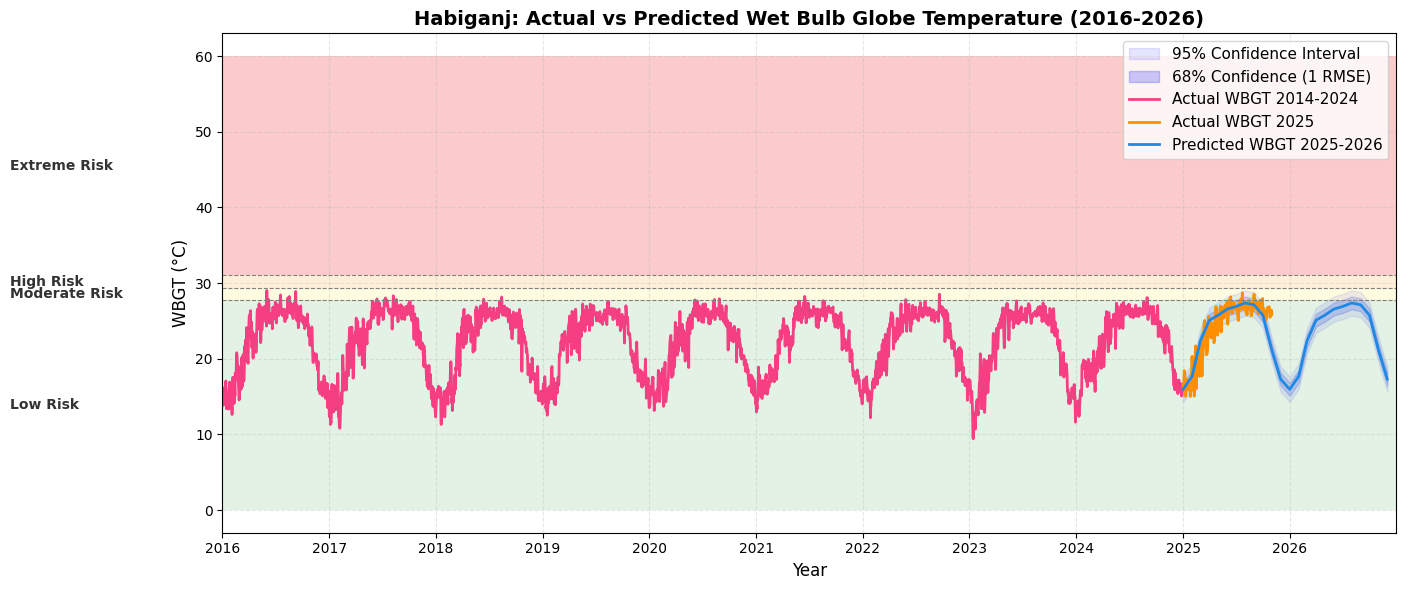

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(14,6))

# --- Ensure datetime index ---
df_WBG_2024 = df_WBG_2024.copy()
df_WBG_2024['date'] = pd.date_range(start='2014-01-01', periods=len(df_WBG_2024))
df_WBG_2024 = df_WBG_2024.set_index('date')

df_WBG_2025 = df_WBG_2025.copy()
df_WBG_2025['date'] = pd.date_range(start='2025-01-01', periods=len(df_WBG_2025))
df_WBG_2025 = df_WBG_2025.set_index('date')

df_WBG = df_WBG.copy()
df_WBG['date'] = pd.date_range(start='2025-01-01', periods=len(df_WBG), freq='MS')
df_WBG = df_WBG.set_index('date')


# --- Filter ranges for plotting ---
df_WBG_2024_plot = df_WBG_2024.loc['2014-01-01':'2024-12-31']
df_WBG_2025_plot = df_WBG_2025.loc['2025-01-01':'2025-12-31']
df_WBG_pred_plot = df_WBG.loc['2025-01-01':'2026-12-31']


# --- Define RMSE for Heat Index ---
# Replace this with your actual Heat Index model RMSE
wbg_rmse #########################################################################  

# Calculate bounds for the prediction DataFrame
df_WBG_pred_plot['upper_95'] = df_WBG_pred_plot['predicted_wet_bulb_C'] + (1.96 * wbg_rmse) # Statistics tells us that in a perfect "Bell Curve" (Normal Distribution), 95% of all values fall within 1.96 standard deviations of the mean.
df_WBG_pred_plot['lower_95'] = df_WBG_pred_plot['predicted_wet_bulb_C'] - (1.96 * wbg_rmse)
df_WBG_pred_plot['upper_68'] = df_WBG_pred_plot['predicted_wet_bulb_C'] + wbg_rmse
df_WBG_pred_plot['lower_68'] = df_WBG_pred_plot['predicted_wet_bulb_C'] - wbg_rmse

# --- Plot the Confidence Cloud ---

# 95% Confidence Interval (Lighter Blue)
plt.fill_between(df_WBG_pred_plot.index, 
                 df_WBG_pred_plot['lower_95'], 
                 df_WBG_pred_plot['upper_95'], 
                 color='blue', alpha=0.1, label='95% Confidence Interval')

# 68% Confidence Interval (Slightly Darker Blue)
plt.fill_between(df_WBG_pred_plot.index, 
                 df_WBG_pred_plot['lower_68'], 
                 df_WBG_pred_plot['upper_68'], 
                 color='blue', alpha=0.2, label='68% Confidence (1 RMSE)')




# --- Plot actual vs predicted WBGT ---
plt.plot(df_WBG_2024_plot.index, df_WBG_2024_plot['wet_bulb_C'],
         label='Actual WBGT 2014-2024', color="#F53F82", linewidth=2)

plt.plot(df_WBG_2025_plot.index, df_WBG_2025_plot['wet_bulb_C'],
         label='Actual WBGT 2025', color='#FF8F00', linewidth=2)

plt.plot(df_WBG_pred_plot.index, df_WBG_pred_plot['predicted_wet_bulb_C'],
         label='Predicted WBGT 2025-2026', color='#1E88E5', linewidth=2)

# --- Risk category bands with labels ---
ax = plt.gca()
bands = [
    (0, 27.8, "Low Risk", "#A5D6A7"),
    (27.8, 29.4, "Moderate Risk", "#FFF59D"),
    (29.4, 31, "High Risk", "#FFCC80"),
    (31, 60, "Extreme Risk", "#EF5350")
]

for start, end, label, color in bands:
    ax.axhspan(start, end, facecolor=color, alpha=0.3)
    # Add text label inside the band
    y_pos = start + (end - start)/2
    ax.text(df_WBG_2024_plot.index[3], y_pos, label,
            fontsize=10, fontweight='bold', color='black', alpha=0.8, va='center')

# --- Threshold lines ---
thresholds = [27.8, 29.4, 31]
for t in thresholds:
    plt.axhline(y=t, color='gray', linestyle='--', linewidth=0.8)

# --- Labels, title, legend ---
plt.xlabel('Year', fontsize=12)
plt.ylabel('WBGT (°C)', fontsize=12)
plt.title(f'{district}: Actual vs Predicted Wet Bulb Globe Temperature (2016-2026)', fontsize=14, fontweight='bold')

plt.legend(frameon=True, fontsize=11)

# --- X-axis formatting ---
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=0)

plt.grid(alpha=0.3, linestyle='--')
plt.xlim(pd.Timestamp('2016-01-01'), pd.Timestamp('2026-12-31'))

plt.tight_layout()
plt.show()

## Calculating Heatstroke Risk

Calculating heatstroke risk using 1980-2024 raw data

In [ ]:
import pandas as pd
import numpy as np

# --- Load datasets ---
df_district_2024 = pd.read_csv(f"../../../1980-2024-dataset/{district}_historical_weather_1980_2024.csv")

df = df_district_2024.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

# --- Monthly resampling and interpolation ---
df_monthly_hum = df.set_index('date')['humidity'].resample('MS').mean().interpolate()
df_monthly_temp = df.set_index('date')['temperature(degree C)'].resample('MS').mean().interpolate()

# --- Heat Index Calculation ---
df_HI_2024 = pd.DataFrame({
    'date': df_monthly_temp.index,
    'temperature': df_monthly_temp.values,
    'humidity': df_monthly_hum.values
})

def calculate_heat_index(temperature_c, humidity):
    t_c = float(temperature_c)
    h = float(humidity)
    if 0.0 <= h <= 1.0:
        h = h * 100.0
    t_f = t_c * 9.0/5.0 + 32.0
    hi = 0.5 * (t_f + 61.0 + ((t_f - 68.0) * 1.2) + (h * 0.094))
    if hi >= 80.0:
        T = t_f
        R = h
        hi = (-42.379 + 2.04901523*T + 10.14333127*R
              - 0.22475541*T*R - 6.83783e-3*T**2
              - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
              + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)
    return (hi - 32.0) * 5.0/9.0

df_HI_2024['heat_index_C'] = df_HI_2024.apply(
    lambda r: calculate_heat_index(r['temperature'], r['humidity']),
    axis=1
)

# --- Wet Bulb Calculation (Stull) ---
df_WB_2024 = pd.DataFrame({
    'date': df_monthly_temp.index,
    'temperature': df_monthly_temp.values,
    'humidity': df_monthly_hum.values
})

def calculate_wet_bulb(T, RH):
    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0
    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )
    return Tw

df_WB_2024['wet_bulb_C'] = df_WB_2024.apply(
    lambda r: calculate_wet_bulb(r['temperature'], r['humidity']),
    axis=1
)

# --- Ensure full 1980-2024 monthly range ---
date_range = pd.date_range(start='1980-01-01', end='2024-12-01', freq='MS')

df_HI_2024 = df_HI_2024.set_index('date').reindex(date_range).interpolate().reset_index()
df_HI_2024.rename(columns={'index':'date'}, inplace=True)

df_WB_2024 = df_WB_2024.set_index('date').reindex(date_range).interpolate().reset_index()
df_WB_2024.rename(columns={'index':'date'}, inplace=True)

# --- Merge datasets ---
df_heatstress_2024 = pd.merge(
    df_HI_2024[['date', 'heat_index_C']],
    df_WB_2024[['date', 'wet_bulb_C']],
    on='date'
)

# --- Heatstroke Risk Function ---
def calculate_heatstroke_risk(heat_index_c, wet_bulb_c):
    HI_F = heat_index_c * 9/5 + 32  # Heat Index in Fahrenheit
    beta0 = -18
    beta1 = 0.15
    risk_hi = 1 / (1 + np.exp(-(beta0 + beta1 * HI_F)))

    if wet_bulb_c >= 35:
        wb_factor = 1.0  # unsurvivable
    elif wet_bulb_c >= 30:
        wb_factor = 0.8  # extreme
    elif wet_bulb_c >= 27:
        wb_factor = 0.5  # moderate
    else:
        wb_factor = 0.2  # low

    risk = risk_hi * wb_factor
    return min(risk, 1)

df_heatstress_2024['heatstroke_risk'] = df_heatstress_2024.apply(
    lambda r: calculate_heatstroke_risk(r['heat_index_C'], r['wet_bulb_C']),
    axis=1
)

#df_heatstress_2024['unsurvivable_flag'] = df_heatstress_2024['wet_bulb_C'] > 35


df_heatstress_2024

,date,heat_index_C,wet_bulb_C,heatstroke_risk
0,1980-01-01,17.865921,14.657501,0.000046
1,1980-02-01,20.718358,16.866117,0.000099
2,1980-03-01,26.274192,21.494620,0.000445
3,1980-04-01,35.024847,25.613013,0.004626
4,1980-05-01,31.999325,25.035490,0.002070
...,...,...,...,...
535,2024-08-01,34.563820,26.658069,0.004095
536,2024-09-01,37.414191,27.293775,0.021591
537,2024-10-01,31.863737,25.715166,0.001997
538,2024-11-01,24.855915,21.672149,0.000304


## 2025 raw data

In [ ]:
import pandas as pd
import numpy as np

# --- Load datasets ---
df_district_2025 = pd.read_csv(f"../../../2025-dataset/{district}_historical_weather_2025.csv")

df = df_district_2025.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

# --- Monthly resampling and interpolation ---
df_monthly_hum = df.set_index('date')['humidity'].resample('MS').mean().interpolate()
df_monthly_temp = df.set_index('date')['temperature(degree C)'].resample('MS').mean().interpolate()

# --- Heat Index Calculation ---
df_HI_2025 = pd.DataFrame({
    'date': df_monthly_temp.index,
    'temperature': df_monthly_temp.values,
    'humidity': df_monthly_hum.values
})

def calculate_heat_index(temperature_c, humidity):
    t_c = float(temperature_c)
    h = float(humidity)
    if 0.0 <= h <= 1.0:
        h = h * 100.0
    t_f = t_c * 9.0/5.0 + 32.0
    hi = 0.5 * (t_f + 61.0 + ((t_f - 68.0) * 1.2) + (h * 0.094))
    if hi >= 80.0:
        T = t_f
        R = h
        hi = (-42.379 + 2.04901523*T + 10.14333127*R
              - 0.22475541*T*R - 6.83783e-3*T**2
              - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
              + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)
    return (hi - 32.0) * 5.0/9.0

df_HI_2025['heat_index_C'] = df_HI_2025.apply(
    lambda r: calculate_heat_index(r['temperature'], r['humidity']),
    axis=1
)

# --- Wet Bulb Calculation (Stull) ---
df_WB_2025 = pd.DataFrame({
    'date': df_monthly_temp.index,
    'temperature': df_monthly_temp.values,
    'humidity': df_monthly_hum.values
})

def calculate_wet_bulb(T, RH):
    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0
    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )
    return Tw

df_WB_2025['wet_bulb_C'] = df_WB_2025.apply(
    lambda r: calculate_wet_bulb(r['temperature'], r['humidity']),
    axis=1
)

date_range = pd.date_range(start='2025-01-01', end='2025-11-01', freq='MS')

df_HI_2025 = df_HI_2025.set_index('date').reindex(date_range).interpolate().reset_index()
df_HI_2025.rename(columns={'index':'date'}, inplace=True)

df_WB_2025 = df_WB_2025.set_index('date').reindex(date_range).interpolate().reset_index()
df_WB_2025.rename(columns={'index':'date'}, inplace=True)

# --- Merge datasets ---
df_heatstress_2025 = pd.merge(
    df_HI_2025[['date', 'heat_index_C']],
    df_WB_2025[['date', 'wet_bulb_C']],
    on='date'
)

# --- Heatstroke Risk Function ---
def calculate_heatstroke_risk(heat_index_c, wet_bulb_c):
    HI_F = heat_index_c * 9/5 + 32  # Heat Index in Fahrenheit
    beta0 = -18
    beta1 = 0.15
    risk_hi = 1 / (1 + np.exp(-(beta0 + beta1 * HI_F)))

    if wet_bulb_c >= 35:
        wb_factor = 1.0  # unsurvivable
    elif wet_bulb_c >= 30:
        wb_factor = 0.8  # extreme
    elif wet_bulb_c >= 27:
        wb_factor = 0.5  # moderate
    else:
        wb_factor = 0.2  # low

    risk = risk_hi * wb_factor
    return min(risk, 1)

df_heatstress_2025['heatstroke_risk'] = df_heatstress_2025.apply(
    lambda r: calculate_heatstroke_risk(r['heat_index_C'], r['wet_bulb_C']),
    axis=1
)

#df_heatstress_2025['unsurvivable_flag'] = df_heatstress_2025['wet_bulb_C'] > 35


df_heatstress_2025

,date,heat_index_C,wet_bulb_C,heatstroke_risk
0,2025-01-01,18.848237,16.647560,0.000060
1,2025-02-01,21.945383,18.513938,0.000138
2,2025-03-01,27.609823,21.963114,0.000637
3,2025-04-01,31.826788,24.609800,0.001977
4,2025-05-01,33.178914,25.828019,0.002836
5,2025-06-01,35.914030,26.829053,0.005844
6,2025-07-01,35.627189,26.900515,0.005420
7,2025-08-01,35.131570,26.684266,0.004758
8,2025-09-01,36.751191,27.188653,0.018181
9,2025-10-01,33.482541,26.058620,0.003074


## Calculating using predicted heat index and wet bulb

In [ ]:
import pandas as pd
import numpy as np

# --- Prepare predicted dataframe ---
df_HI = pd.DataFrame()
df_HI['predicted_temp'] = df_predictions_temp['predicted_temp'].values
df_HI['predicted_humidity'] = df_predictions_humidity['predicted_humidity'].values

# --- Create date column with exact length matching ---
num_rows = len(df_HI)
date_range = pd.date_range(start='2025-01-01', periods=num_rows, freq='MS')
df_HI['date'] = date_range

# --- Heat Index calculation ---
def calculate_heat_index(temperature_c, humidity):
    t_c = float(temperature_c)
    h = float(humidity)
    # Ensure humidity is in %
    if 0.0 <= h <= 1.0:
        h = h * 100.0
    # Convert Celsius to Fahrenheit
    t_f = t_c * 9/5 + 32
    # Simple heat index formula
    hi = 0.5 * (t_f + 61 + ((t_f - 68) * 1.2) + (h * 0.094))
    if hi >= 80:
        T, R = t_f, h
        hi = (-42.379 + 2.04901523*T + 10.14333127*R
              - 0.22475541*T*R - 6.83783e-3*T**2
              - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
              + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)
    # Convert back to Celsius
    return (hi - 32) * 5/9

df_HI['heat_index_C'] = df_HI.apply(
    lambda r: calculate_heat_index(r['predicted_temp'], r['predicted_humidity']),
    axis=1
)

# --- Wet Bulb calculation ---
def calculate_wet_bulb(T, RH):
    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0
    Tw = (T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
          + np.arctan(T + RH)
          - np.arctan(RH - 1.676331)
          + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
          - 4.686035)
    return Tw

df_HI['wet_bulb_C'] = df_HI.apply(
    lambda r: calculate_wet_bulb(r['predicted_temp'], r['predicted_humidity']),
    axis=1
)

# --- Heatstroke risk calculation ---
def calculate_heatstroke_risk(heat_index_c, wet_bulb_c):
    HI_F = heat_index_c * 9/5 + 32  # Convert to Fahrenheit for risk formula
    beta0 = -18
    beta1 = 0.15
    risk_hi = 1 / (1 + np.exp(-(beta0 + beta1 * HI_F)))
    # Wet bulb adjustment factor
    if wet_bulb_c >= 35:
        wb_factor = 1.0
    elif wet_bulb_c >= 30:
        wb_factor = 0.8
    elif wet_bulb_c >= 27:
        wb_factor = 0.5
    else:
        wb_factor = 0.2
    risk = risk_hi * wb_factor
    return min(risk, 1)

df_HI['heatstroke_risk'] = df_HI.apply(
    lambda r: calculate_heatstroke_risk(r['heat_index_C'], r['wet_bulb_C']),
    axis=1
)

# --- Final dataframe ---
df_heatstress = df_HI[['date', 'heat_index_C', 'wet_bulb_C', 'heatstroke_risk']]
df_heatstress

,date,heat_index_C,wet_bulb_C,heatstroke_risk
0,2025-01-01,17.802053,15.948599,0.000045
1,2025-02-01,20.741625,17.685966,0.000100
2,2025-03-01,26.563697,22.331094,0.000481
3,2025-04-01,32.996616,25.082859,0.002701
4,2025-05-01,33.734919,25.744898,0.003288
5,2025-06-01,34.652784,26.558313,0.004193
6,2025-07-01,36.043985,26.898976,0.006047
7,2025-08-01,37.415273,27.366623,0.021597
8,2025-09-01,36.307849,27.122132,0.016197
9,2025-10-01,32.236245,25.742266,0.002206


# Heat Stroke

C:\Users\Khalid\AppData\Local\Temp\ipykernel_21580\1732288753.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_heatstress['date'] = pd.to_datetime(df_heatstress['date'])
C:\Users\Khalid\AppData\Local\Temp\ipykernel_21580\1732288753.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_heatstress['Heat_Severity'] = df_heatstress['heat_index_C'].apply(categorize_risk)


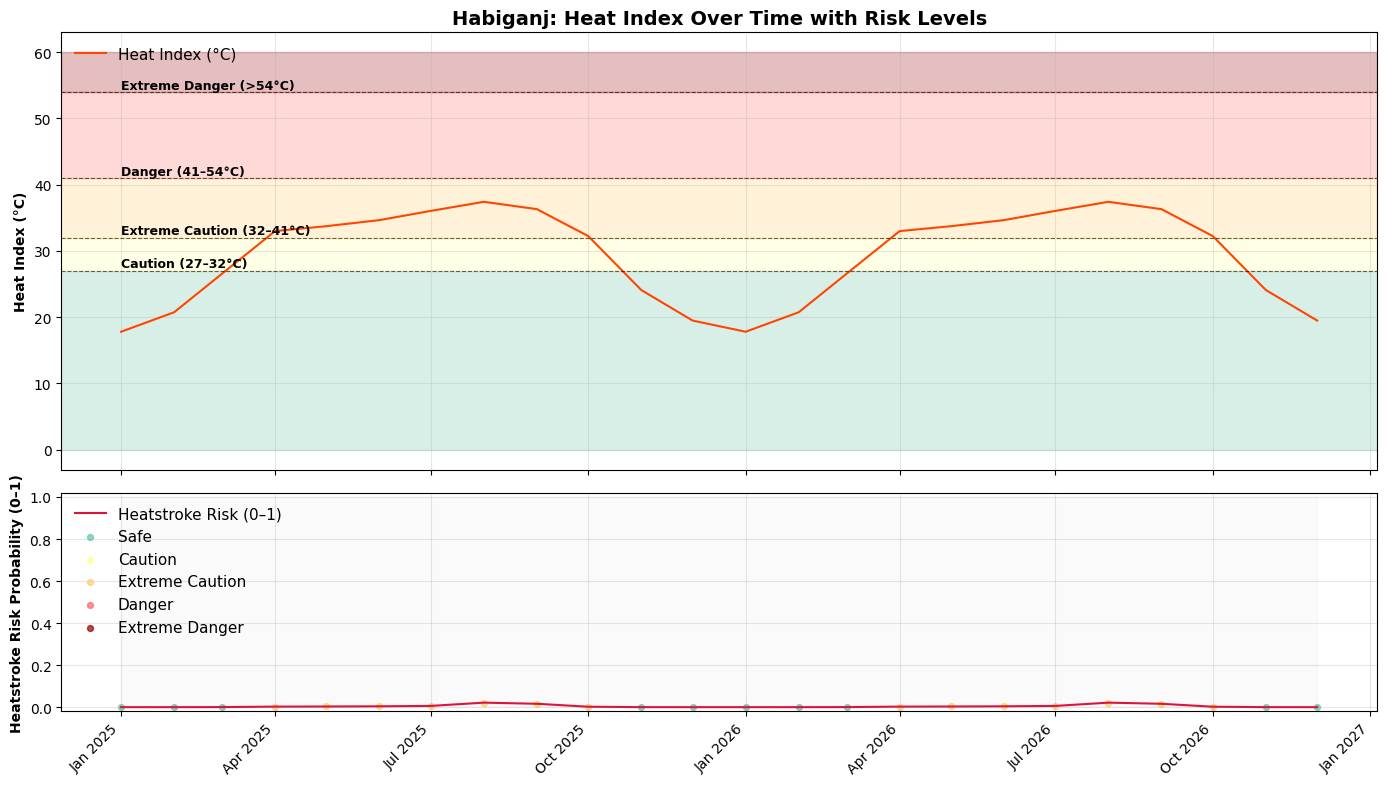

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# --- Convert date column ---
df_heatstress['date'] = pd.to_datetime(df_heatstress['date'])

# --- Categorize Heat Severity based on NOAA thresholds ---
def categorize_risk(hi_c):
    if hi_c > 54:           # Extreme danger (>54°C)
        return 'Extreme Danger'
    elif hi_c > 41:         # Danger (41–54°C)
        return 'Danger'
    elif hi_c > 32:         # Extreme caution (32–41°C)
        return 'Extreme Caution'
    elif hi_c > 27:         # Caution (27–32°C)
        return 'Caution'
    else:
        return 'Safe'

df_heatstress['Heat_Severity'] = df_heatstress['heat_index_C'].apply(categorize_risk)

# --- Color palette for categories ---
palette = {
    'Safe':'#66c2a5',              # Green
    'Caution':'#ffff99',           # Yellow
    'Extreme Caution':'#ffcc66',   # Orange
    'Danger':'#ff6666',            # Red
    'Extreme Danger':'#990000'     # Dark Red
}

# --- Plot setup ---
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(14,8), sharex=True, gridspec_kw={'height_ratios':[2,1]})
plt.rcParams.update({'font.size': 11})

# --- Heat Index plot (ax1) ---
ax1.plot(df_heatstress['date'], df_heatstress['heat_index_C'], color='orangered', lw=1.5, label='Heat Index (°C)')

# --- Add NOAA heat index bands as shaded background ---
bands = [
    (0, 27, '#66c2a5', 'Safe (<27°C)'),
    (27, 32, '#ffff99', 'Caution (27–32°C)'),
    (32, 41, '#ffcc66', 'Extreme Caution (32–41°C)'),
    (41, 54, '#ff6666', 'Danger (41–54°C)'),
    (54, 60, '#990000', 'Extreme Danger (>54°C)')
]

for start, end, color, label in bands:
    ax1.axhspan(start, end, color=color, alpha=0.25)

# --- Add threshold lines and labels ---
for start, end, color, label in bands[1:]:
    ax1.axhline(start, color='k', lw=0.8, ls='--', alpha=0.6)
    ax1.text(df_heatstress['date'].iloc[0], start + 0.5, label, fontsize=9, color='k', weight='bold')

ax1.set_ylabel('Heat Index (°C)', weight='bold')
ax1.set_title(f'{district}: Heat Index Over Time with Risk Levels', weight='bold', fontsize=14)
ax1.grid(alpha=0.3)
ax1.legend(loc='upper left', frameon=False)

# --- Heatstroke risk plot (ax2) ---
ax2.fill_between(df_heatstress['date'], 0, 1, color='lightgrey', alpha=0.1)  # subtle background
ax2.plot(df_heatstress['date'], df_heatstress['heatstroke_risk'], color='crimson', lw=1.5, label='Heatstroke Risk (0–1)')

# Color-coded scatter points
for severity, color in palette.items():
    subset = df_heatstress[df_heatstress['Heat_Severity'] == severity]
    ax2.scatter(subset['date'], subset['heatstroke_risk'], s=18, color=color, label=severity, alpha=0.7)

ax2.set_ylabel('Heatstroke Risk Probability (0–1)', weight='bold')
ax2.set_ylim(-0.02,1.02)
ax2.grid(alpha=0.3)
ax2.legend(loc='upper left', frameon=False)

# --- X-axis formatting ---
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()